## Airbnb Data Investigation and Cleaning

-----------------------------------------------------------
### This Project: Price Prediction In Prague

#### Data Description:
##### a) listings: accommadation info, which includes price, the host, reviews of bookers, accommadation features.
##### b) reviews: the booking reviews for the listings
##### c) neighborhood: the area edges and neighborhood infos of Prague(neighborhood infos is the same as the neighborhood_cleansed in listing table)
##### d) calendar: the predicted price for all the listings( the date in calendar is a future date relative to the data scrabing date)

------------------------------------------------------------
#### 1. EDA (d->c->b->a)

#### 2. feature selection




In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import gc
import geopandas as gpd
import subprocess
import json
from data_prepro_func import get_release_df,get_validate_url,get_release_geodf,select_features_by_rf
from datetime import date, datetime
from shapely.geometry import Point
from pandas.api.types import is_string_dtype, is_bool_dtype, is_numeric_dtype
from dython.nominal import associations
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from feature_selection import select_features_by_rf, auto_vif_drop
from sklearn.feature_selection import f_regression

-----------------------------------------------------------------------
#### 1. EDA (d->c->b->a)
##### d)calendar


In [4]:
# Calendar data
# Calendar data loading and basic analysis and foreign key is listing_id, 
calendar_df = get_release_df("calendar.csv.gz")
print(calendar_df.describe(include='all'))
calendar_df.head()
calendar_counts_by_date = calendar_df.groupby('date').count()['listing_id']
print(calendar_counts_by_date.index.size,calendar_counts_by_date.sort_index().tail(5),calendar_counts_by_date.sort_index().head(5))

Attempting to validate URL link
URL successfully validated! Preparing to read data from link
          listing_id        date available  price  adjusted_price  \
count   3.954411e+06     3954411   3954411    0.0             0.0   
unique           NaN         366         2    NaN             NaN   
top              NaN  2025-09-24         f    NaN             NaN   
freq             NaN       10834   2006447    NaN             NaN   
mean    7.175051e+17         NaN       NaN    NaN             NaN   
std     5.812324e+17         NaN       NaN    NaN             NaN   
min     2.316300e+04         NaN       NaN    NaN             NaN   
25%     3.736026e+07         NaN       NaN    NaN             NaN   
50%     8.677884e+17         NaN       NaN    NaN             NaN   
75%     1.262450e+18         NaN       NaN    NaN             NaN   
max     1.516083e+18         NaN       NaN    NaN             NaN   

        minimum_nights  maximum_nights  
count     3.954411e+06    3.954411e+0

##### this table is used for prediction task. you need to predite the price for the listing id in one year, the 2025-09-23 is few because of the scrabe date.

In [5]:

## neiborhood data
from data_prepro_func import get_validate_url, infer_json_schema
data_url = get_validate_url("neighbourhoods.geojson")
response = requests.get(data_url)
geojson_data = response.json()
def infer_json_schema(data):
    """
    recursively get the structure of the geojson data until fetch the basic type of python, like int,str,bool...
    """
    # 1. if dict, get the children structure
    if isinstance(data, dict):
        return {key: infer_json_schema(value) for key, value in data.items()}
    
    # 2. if the type is list, then find the type of elements
    elif isinstance(data, list):
        if len(data) == 0:
            return "List[Empty]"
        
        return f"List -> {infer_json_schema(data[0])}"
    
    
    else:
        if data is None:
            return "NoneType "
        return f"{type(data).__name__} "

#tree structure of the geojson data
print(geojson_data.keys())
first_feature = geojson_data['features'][0]
auto_schema = infer_json_schema(first_feature)

print(" --- automated schema --- \n")
print(json.dumps(auto_schema, indent=4, ensure_ascii=False))
#present the details of the first feature
print("\n --- the first feature data --- \ n")
print(json.dumps(first_feature, indent=4, ensure_ascii=False))
for index, feature in enumerate(geojson_data['features'], start=1):
    props = feature['properties']
    
    # get the neighborhood name and group, with default values if they are missing
    name = props.get('neighbourhood', 'Unknown')
    group = str(props.get('neighbourhood_group', 'None'))
    
    # print the index, name, and group in a formatted way
    print(f"[{index:<3}] {name:<30} {group}")

<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_63091/3975550620.py:35: SyntaxWarning: invalid escape sequence '\ '
  print("\n --- the first feature data --- \ n")


Attempting to validate URL link
response.status_code:200
URL successfully validated! Preparing to read data from link
dict_keys(['type', 'features'])
 --- automated schema --- 

{
    "type": "str ",
    "geometry": {
        "type": "str ",
        "coordinates": "List -> List -> List -> List -> float "
    },
    "properties": {
        "neighbourhood": "str ",
        "neighbourhood_group": "NoneType "
    }
}

 --- the first feature data --- \ n
{
    "type": "Feature",
    "geometry": {
        "type": "MultiPolygon",
        "coordinates": [
            [
                [
                    [
                        14.410885,
                        50.078674
                    ],
                    [
                        14.409818,
                        50.079065
                    ],
                    [
                        14.409493,
                        50.079838
                    ],
                    [
                        14.40913,
                

Neiborhood data includes the edge of the 57 district of prague, so leave here and for the later investigation, ob the price or other features are correlated with districts.


In [6]:
## reviews data and see the details in data wranglerling part
from data_prepro_func import get_release_df
reviews_df = get_release_df("reviews.csv.gz")
print(reviews_df.describe(include='all'))
print(reviews_df.head())

Attempting to validate URL link
URL successfully validated! Preparing to read data from link
          listing_id            id        date   reviewer_id reviewer_name  \
count   8.437710e+05  8.437710e+05      843771  8.437710e+05        843771   
unique           NaN           NaN        5073           NaN        101801   
top              NaN           NaN  2025-06-01           NaN         David   
freq             NaN           NaN        1686           NaN          5520   
mean    2.936958e+17  7.921649e+17         NaN  2.328107e+08           NaN   
std     4.584361e+17  5.447896e+17         NaN  1.956820e+08           NaN   
min     2.316300e+04  4.066800e+04         NaN  7.960000e+02           NaN   
25%     1.501161e+07  6.325209e+08         NaN  5.901992e+07           NaN   
50%     3.192175e+07  9.419153e+17         NaN  1.753229e+08           NaN   
75%     6.839430e+17  1.262212e+18         NaN  4.056379e+08           NaN   
max     1.512906e+18  1.516684e+18         NaN  7

#### Results:
##### 1.reviews data is about the reviews info and the foreign key is the listing_id, which can be used to link with the listings data. The reviews data contains the review_id, listing_id, date, reviewer_id, reviewer_name, comments. The date column is in string format and needs to be converted to datetime format for further analysis. The reviewer_id and reviewer_name columns can be used to analyze the reviewers' behavior and preferences. The comments column contains the actual review text, which can be analyzed for sentiment and topic modeling.
##### 2.notice the reveiws are written in different languages, which may require language detection and translation for further analysis. The reviews data can be used to analyze the overall sentiment of the reviews, identify common themes and topics in the reviews, and analyze the behavior and preferences of the reviewers.
##### 3.9883 distinct listings_id
##### 4.reviews contents are not numeric data, which may require natural language processing techniques for analysis. The reviews data can be used to analyze the overall sentiment of the reviews, identify common themes and topics in the reviews, and analyze the behavior and preferences of the reviewers. The date column can be used to analyze the trends and patterns in the reviews over time. The reviewer_id and reviewer_name columns can be used to analyze the reviewers' behavior and preferences, such as how many reviews they have written, what types of listings they have reviewed, and what their overall sentiment is towards the listings they have reviewed.
##### 5.anaylse the time ranges of reviews for different listing id review counts.


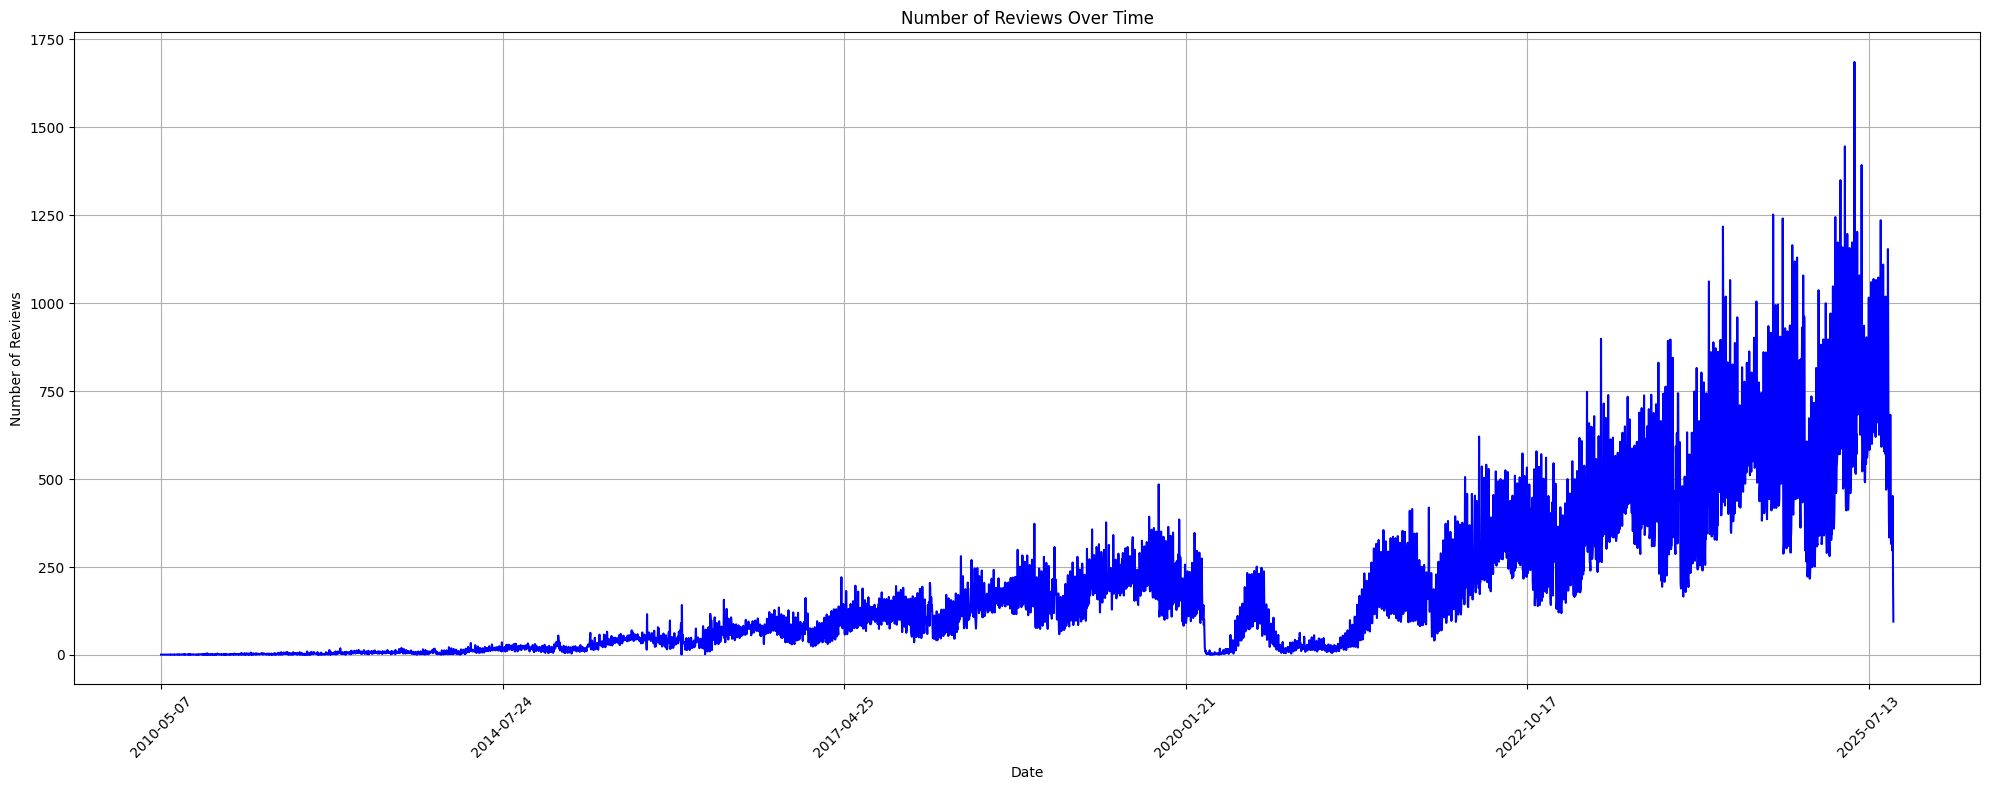

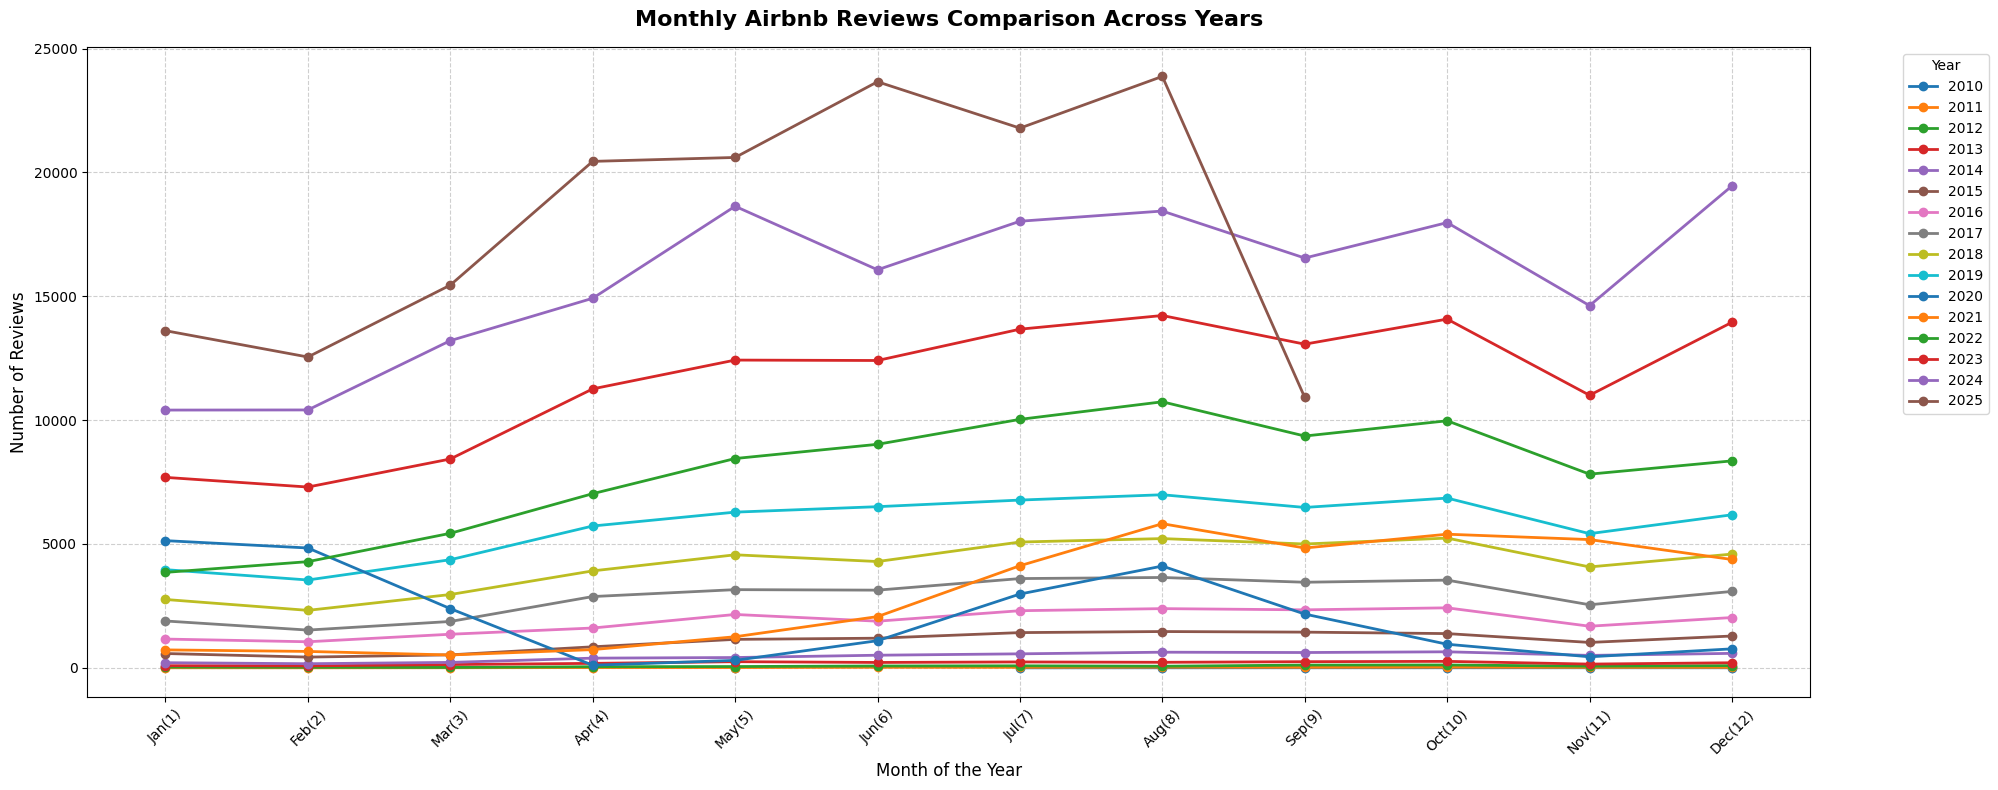

In [7]:
# relation between counts of reviews and date
reviews_counts_by_date = reviews_df.groupby('date').count()['comments']
plt.figure(figsize=(20, 8))
reviews_counts_by_date.plot(kind='line', color='blue')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# check if the comments counts periodical pattern( relation between counts and every month in different years  )

reviews_df['date'] = pd.to_datetime(reviews_df['date'])
reviews_df['year'] = reviews_df['date'].dt.year
reviews_df['month'] = reviews_df['date'].dt.month
monthly_trends = reviews_df.groupby(['year', 'month']).size().reset_index(name='review_count')
pivot_trends = monthly_trends.pivot(index='month', columns='year', values='review_count')
plt.figure(figsize=(20, 8))
pivot_trends.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)
plt.title('Monthly Airbnb Reviews Comparison Across Years', fontsize=16, pad=15, weight='bold')
plt.xlabel('Month of the Year', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# customize x-ticks to show month names and rotate them for better readability
plt.xticks(range(1, 13), labels=[f'Jan({1})', 'Feb(2)', 'Mar(3)', 'Apr(4)', 'May(5)', 'Jun(6)', 'Jul(7)', 'Aug(8)', 'Sep(9)', 'Oct(10)', 'Nov(11)', 'Dec(12)'])
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

#### Results:
##### 1.results show that the review counts increase significantly from 2010, the whole trend is increasing, except for the year 2020,2021, which may be due to the impact of the pandemic and travel rrestrictions.
##### 2..reviews counts show periodical pattern, the review counts are slightly higher in the summer.

In [8]:
## a): listings
## let's move to the most important data, listings data
#data loading and basic analysis 

listings_df = get_release_df("listings.csv.gz")
print(listings_df.shape)
print(listings_df.describe(include='all'))
print(listings_df.head())
print(listings_df.columns)
print(len(listings_df.columns))
print(listings_df.info())


Attempting to validate URL link
URL successfully validated! Preparing to read data from link
(10834, 79)
                  id                         listing_url     scrape_id  \
count   1.083400e+04                               10834  1.083400e+04   
unique           NaN                               10834           NaN   
top              NaN  https://www.airbnb.com/rooms/23163           NaN   
freq             NaN                                   1           NaN   
mean    7.175053e+17                                 NaN  2.025092e+13   
std     5.812591e+17                                 NaN  0.000000e+00   
min     2.316300e+04                                 NaN  2.025092e+13   
25%     3.736095e+07                                 NaN  2.025092e+13   
50%     8.677969e+17                                 NaN  2.025092e+13   
75%     1.262448e+18                                 NaN  2.025092e+13   
max     1.516083e+18                                 NaN  2.025092e+13   

      

In [9]:
# first delete some columns that are not useful for the analysis, such as url, scrape_id,last_scraped,source, theses info tell us the data is scaped on 2025-09-23, and the source is inside airbnb website, which is not useful for the analysis, and the scrape_id is also not useful for the analysis, which is just a unique identifier for each scrape, without repeated id
# why scrape info is not useful.

print(listings_df.groupby(['scrape_id','last_scraped','source']).size())
print(listings_df.groupby(['id','last_scraped']).size().sort_values(ascending=False).head(10))
print(listings_df.groupby(['id','source']).size().sort_index().sort_values(ascending=False).head(10))
unused_cols = ['listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url','host_url','host_thumbnail_url', 'host_picture_url']

#from listings_df.info() there are some columns that have no values
empty_cols = listings_df.columns[listings_df.isna().all()]

#delete some columns
delete_columns = unused_cols + list(empty_cols)
print(f"deleting columns:{delete_columns}")
listings_df.drop(columns=delete_columns, inplace=True, errors='ignore')

scrape_id       last_scraped  source         
20250923203415  2025-09-23    city scrape        1849
                2025-09-24    city scrape        7725
                              previous scrape    1260
dtype: int64
id     last_scraped
23163  2025-09-24      1
23169  2025-09-24      1
26755  2025-09-24      1
30762  2025-09-24      1
42514  2025-09-24      1
52148  2025-09-24      1
55856  2025-09-24      1
75298  2025-09-24      1
79373  2025-09-24      1
79381  2025-09-24      1
dtype: int64
id     source         
23163  previous scrape    1
23169  city scrape        1
26755  city scrape        1
30762  city scrape        1
42514  city scrape        1
52148  city scrape        1
55856  city scrape        1
75298  city scrape        1
79373  city scrape        1
79381  previous scrape    1
dtype: int64
deleting columns:['listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url', 'neighbourhood_group_cleansed', 'calend

In [10]:
# after deleting some columns, we can see the remaining columns and the data types of each column, which can help us to understand the data better and prepare for the next step of data analysis and modeling.
print(listings_df.columns)
print(listings_df.info())


# adjust the data value according the data type
# special for the str(date) to date and calculate the days until today, str(numerical data) to numeric data
date_cols = ['host_since','calendar_last_scraped','first_review','last_review']
numeric_cols = ['host_response_rate','host_acceptance_rate']
for col in date_cols:
    # assign the value type to  date
    listings_df[col] = pd.to_datetime(listings_df[col], errors='coerce').dt.date
    new_col_name = f"{col}_clean"
    listings_df[new_col_name] = (pd.to_datetime(date.today()) - pd.to_datetime(listings_df[col])).dt.days

for col in numeric_cols:
    #remove % sign and then change the type to 0-1 float value
    
    listings_df[col] = pd.to_numeric(
        listings_df[col].astype(str).str.replace('%', '', regex=False), 
        errors='coerce'
    ) / 100.0
#listings_df['price'] = pd.to_numeric(
#        listings_df['price'].astype(str).str.replace('$', '', regex=False), 
#        errors='coerce'
#    ) 
listings_df['price'] = pd.to_numeric(
    listings_df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False), 
    errors='coerce'
)




Index(['id', 'name', 'description', 'neighborhood_overview', 'host_id',
       'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped', 'number_of_reviews',
       'number_of_revi

In [11]:
#first analyze duplicated data of host id and host_name

# 1. view all host_id with multiple host_name
distinct_host_name_counts = listings_df.groupby('host_id')['host_name'].nunique()
assert distinct_host_name_counts.max() == 1, f"find mistake in host_name: {distinct_host_name_counts.max()}"

print("host_id and host_name are in a one-to-one relationship, no duplicates found.")


bad_host_ids = distinct_host_name_counts[distinct_host_name_counts >= 2].index

# 2. report these suspicious host_id and their corresponding host_names if there are any duplicates 
if len(bad_host_ids) > 0:
    print(f"duplicates found for {len(bad_host_ids)} bad host_id(s): {bad_host_ids.tolist()}")
    
    # detail report of these bad host_id and their corresponding host_names
    report = listings_df[listings_df['host_id'].isin(bad_host_ids)][['host_id', 'host_name']].drop_duplicates().sort_values('host_id')
    print(report)



host_id and host_name are in a one-to-one relationship, no duplicates found.


In [12]:
#relation between the host_id  and name
distinct_host_id_counts =listings_df.groupby('name')['host_id'].nunique()
distinct_name_counts = listings_df.groupby('host_id')['name'].nunique()
if distinct_host_id_counts.max() >1:
    print(f"find differet host used the same hotel name")
else:
    print("no different host used the same hotel name, no duplicates found.")

if distinct_name_counts.max() >1:
    print(f"find one host have different hotel properties")
else:
    print("no one host have different hotel properties, no duplicates found.")


find differet host used the same hotel name
find one host have different hotel properties


##### find differet host used the same hotel name
##### find one host have different hotel properties


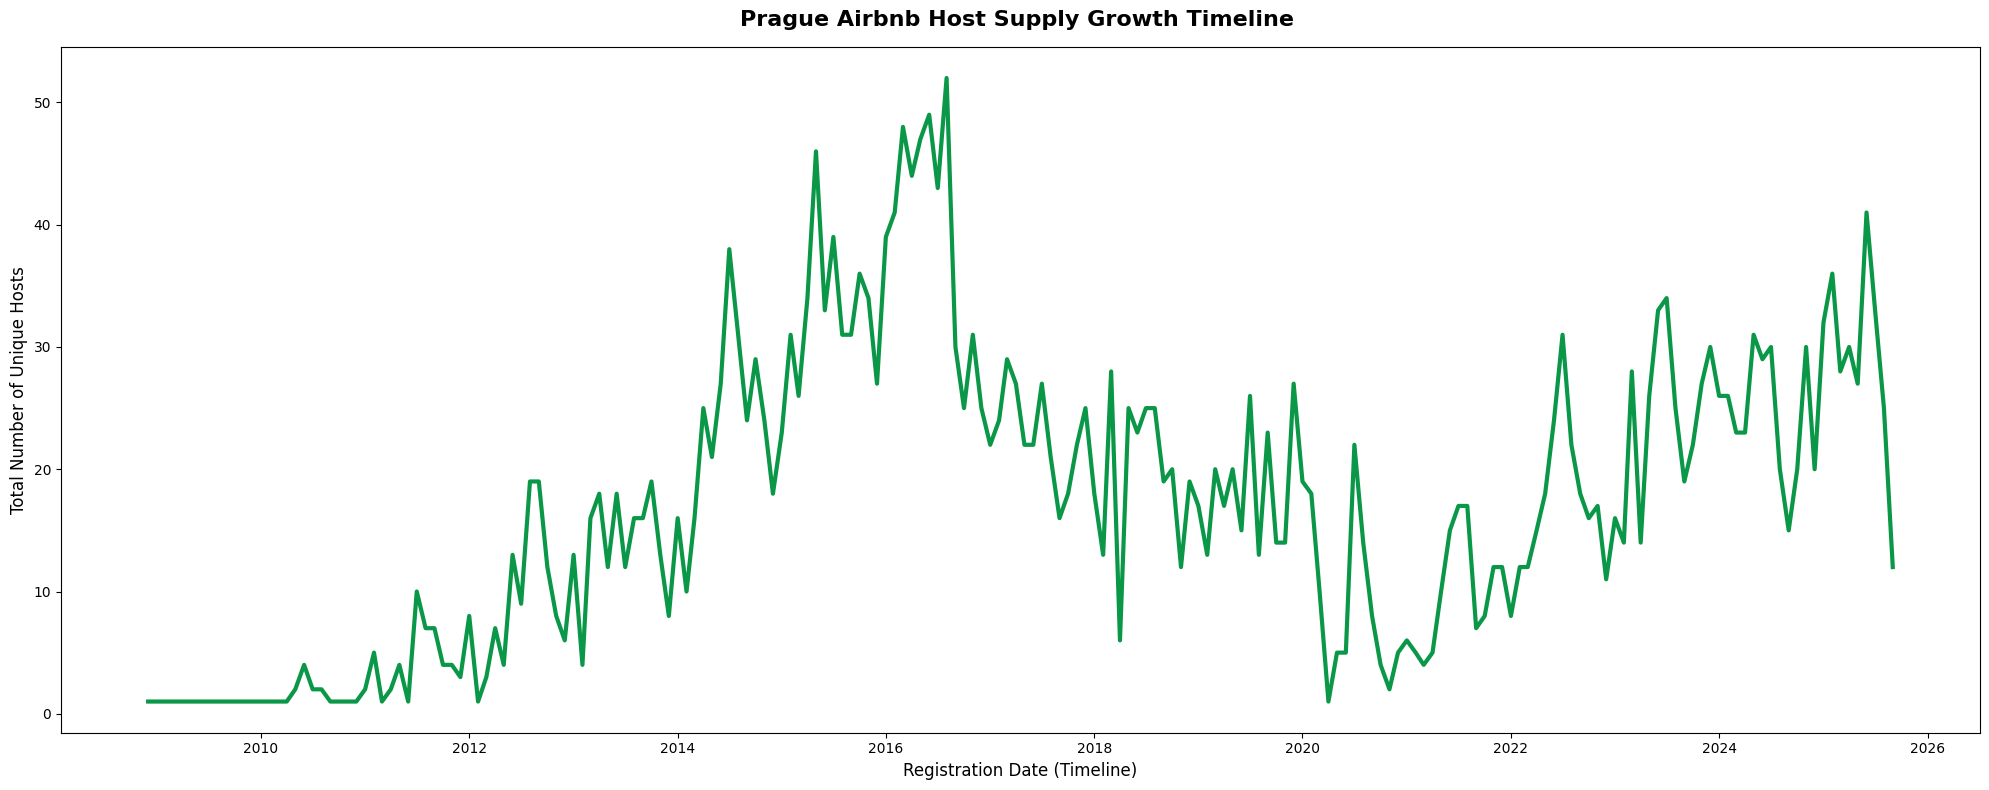

In [13]:
#host investigation
#remove duplicates
df_hosts = listings_df[['host_id', 'host_since']].dropna().drop_duplicates(subset=['host_id'])
#the total number of new hosts in every month
df_hosts['year_month'] = df_hosts['host_since'].apply(lambda x: x.strftime('%Y-%m'))
monthly_growth = df_hosts.groupby('year_month').size().reset_index(name='new_hosts')
monthly_growth['year_month'] = pd.to_datetime(monthly_growth['year_month'])
#plot 
fig, ax = plt.subplots(figsize=(20, 8))
plt.rcParams['font.family'] = 'sans-serif'
ax.plot(
    monthly_growth['year_month'], 
    monthly_growth['new_hosts'], 
    color="#0A9848",      
    linewidth=3, 
    label='New Registered Hosts'
)
#title 
ax.set_title("Prague Airbnb Host Supply Growth Timeline ", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Registration Date (Timeline)", fontsize=12)
ax.set_ylabel("Total Number of Unique Hosts", fontsize=12)
plt.tight_layout()
plt.show()


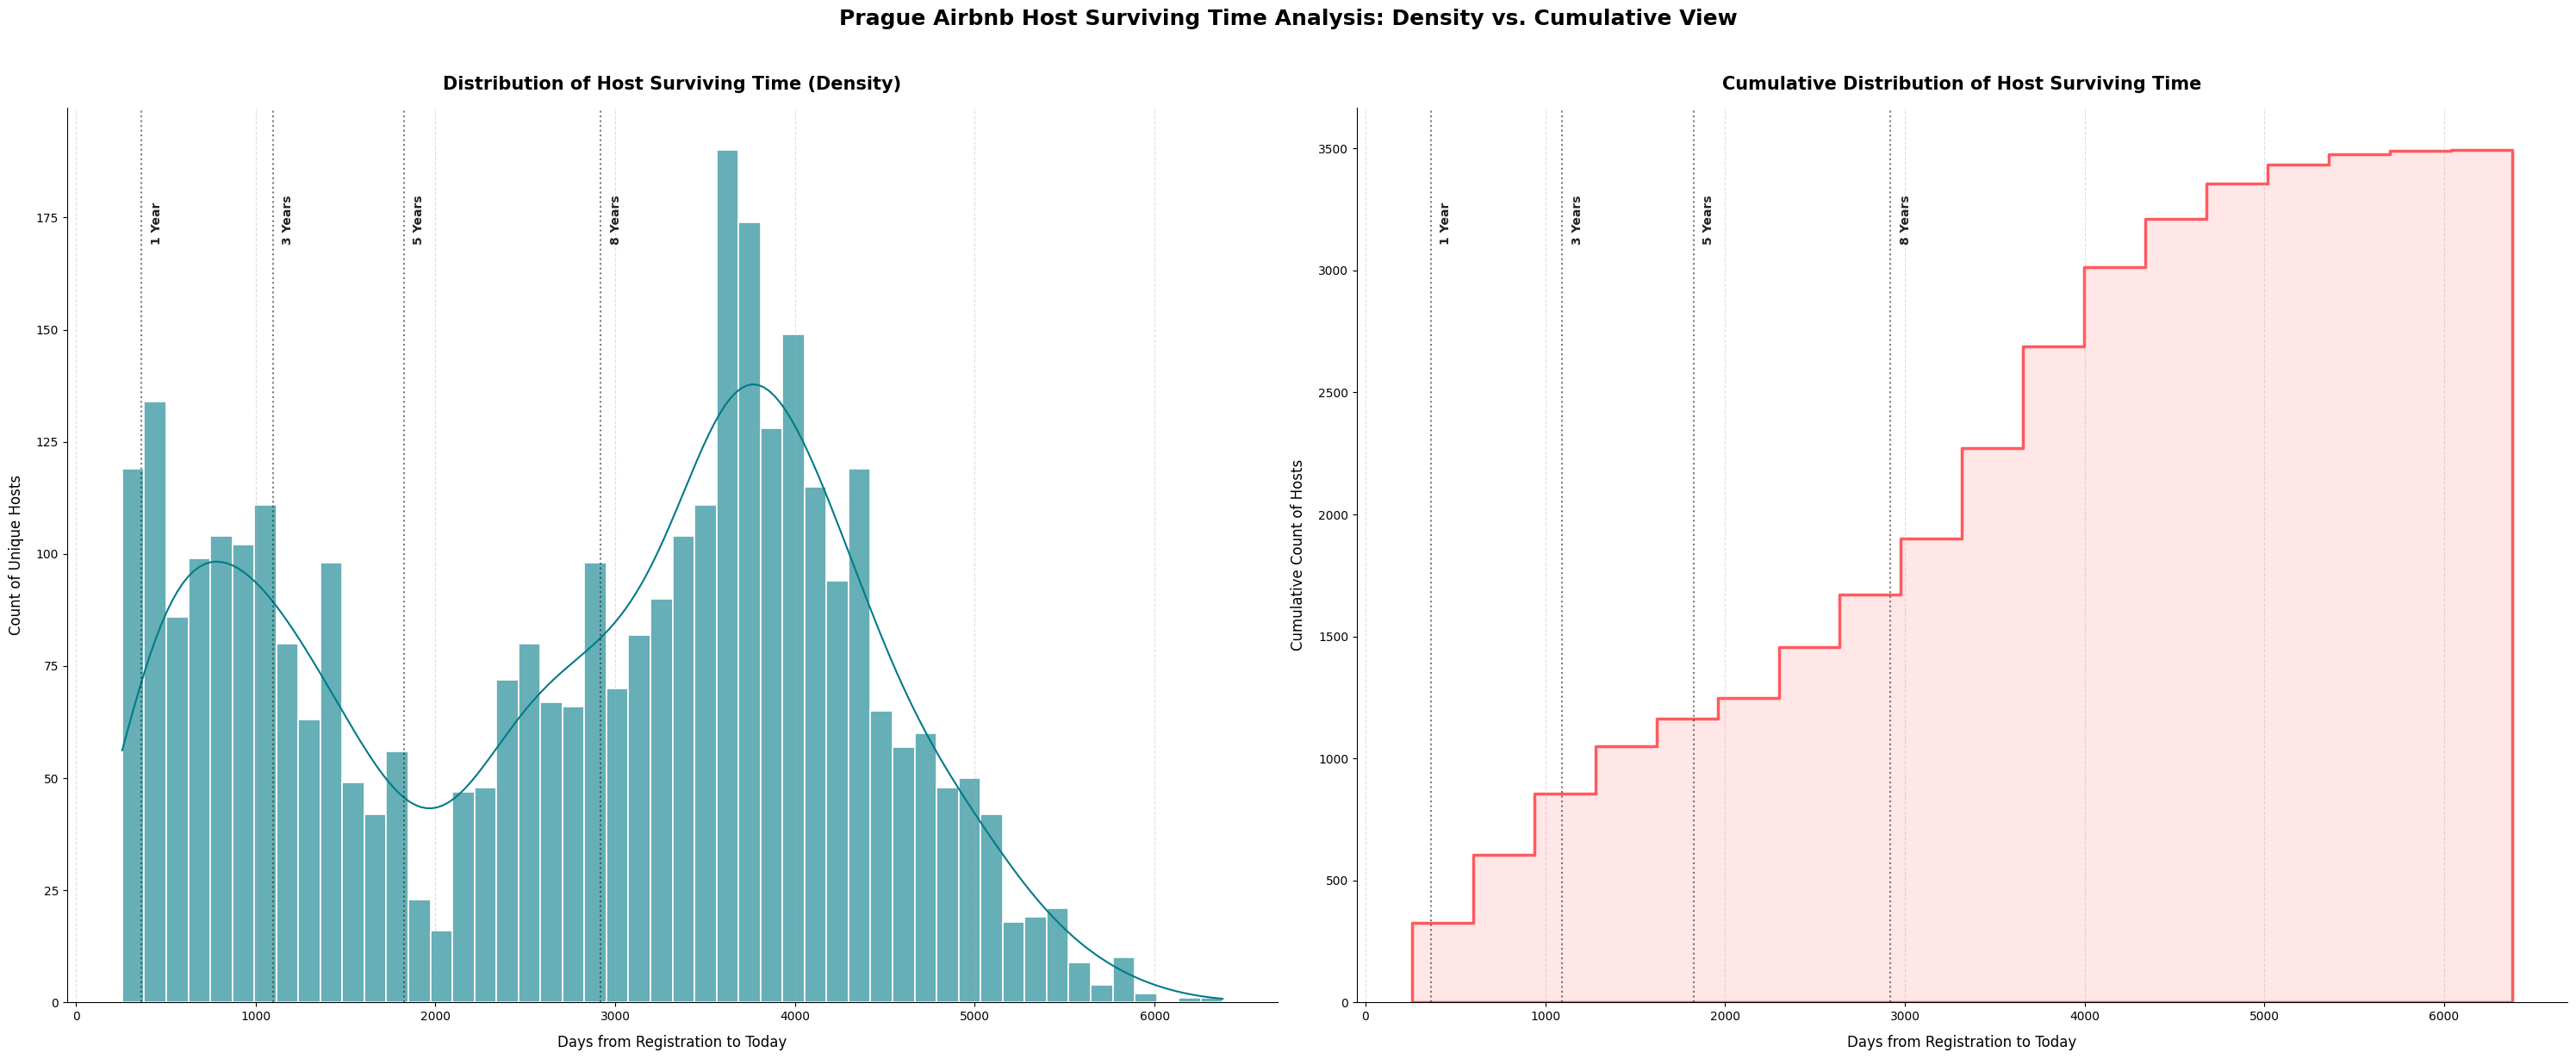

In [14]:

# register days distribution (date reference sys.today())
df_hosts['days_since_reg'] = (pd.to_datetime(date.today()) - pd.to_datetime(df_hosts['host_since'])).dt.days
df_hosts = df_hosts[df_hosts['days_since_reg'] >= 0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 12))

plt.rcParams['font.family'] = 'sans-serif'
# sns plot
sns.histplot(
    data=df_hosts,
    x='days_since_reg',
    kde=True,                 # smooth density distribution
    bins=50,                  # bin 
    color='#007A87',          
    edgecolor='white',   
    linewidth=1.2,
    alpha=0.6,
    ax=ax1
)
#cumulative days

sns.histplot(
    data=df_hosts, x='days_since_reg', 
    cumulative=True,           # cumulative
    element='step',           
    fill=True,                 
    color='#FF5A5F',           
    alpha=0.15,
    linewidth=2.5,
    ax=ax2
)
#add reference days 
milestones = {
    365: '1 Year',
    1095: '3 Years',
    1825: '5 Years',
    2920: '8 Years'
}
milestones = {365: '1 Year', 1095: '3 Years', 1825: '5 Years', 2920: '8 Years'}

for ax, title, ylabel in zip(
    [ax1, ax2], 
    ["Distribution of Host Surviving Time (Density)", "Cumulative Distribution of Host Surviving Time"],
    ["Count of Unique Hosts", "Cumulative Count of Hosts"]
):
    #max y 
    max_y = ax.get_ylim()[1]
    
    for days, label in milestones.items():
        if days < df_hosts['days_since_reg'].max():
            ax.axvline(x=days, color='#222222', linestyle=':', linewidth=1.5, alpha=0.6)
            ax.text(
                x=days + 50, y=max_y * 0.85, s=label, 
                color='#222222', fontsize=10, fontweight='bold', rotation=90
            )
            
    # title 
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel("Days from Registration to Today", fontsize=12, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10)
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Prague Airbnb Host Surviving Time Analysis: Density vs. Cumulative View", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

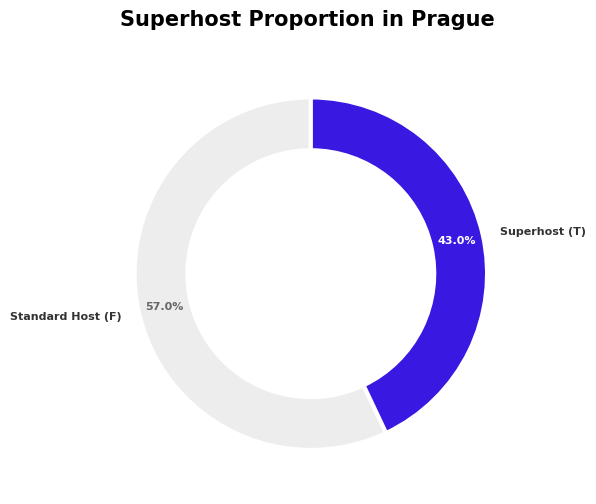

In [15]:
## Super host is an high-quality host standard,an important character of host

# 1. is_superhost， T and the rest is F(include NAN)
is_super = (listings_df['host_is_superhost'] == 't').value_counts()
f_count = is_super.get(False, 0)
t_count = is_super.get(True, 0)

# 2. data 
labels = ['Standard Host (F)', 'Superhost (T)']
sizes = [f_count, t_count]
colors = ['#EDEDED', "#3918E1"] 

fig, ax = plt.subplots(figsize=(6, 6))

# 3. ring 
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',       
    startangle=90,           
    pctdistance=0.85,       
    textprops=dict(color="#333333", size=8
                   , weight="bold"), 
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=3) 
)

# 4. polish
autotexts[0].set_color('#666666') 
autotexts[1].set_color('white')   

ax.set_title("Superhost Proportion in Prague ", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

________________________
The volume of newly registered hosts initially expanded rapidly,
 but entered a downward trajectory following its peak, largely due to the pandemic.
   Recently, the market has shown signs of a resurgence, though it has yet to fully return to historical levels. 
   Interestingly, the expected seasonal fluctuations are relatively muted in this dataset. 
   Furthermore, a detailed survival analysis reveals that the 5-year mark represents a critical inflection point
   , as many hosts encounter significant operational challenges and exit the market around this period.
   The hosts in Prague have higher quality.
________________________

Codespaces already has 'neighbourhoods.geojson'


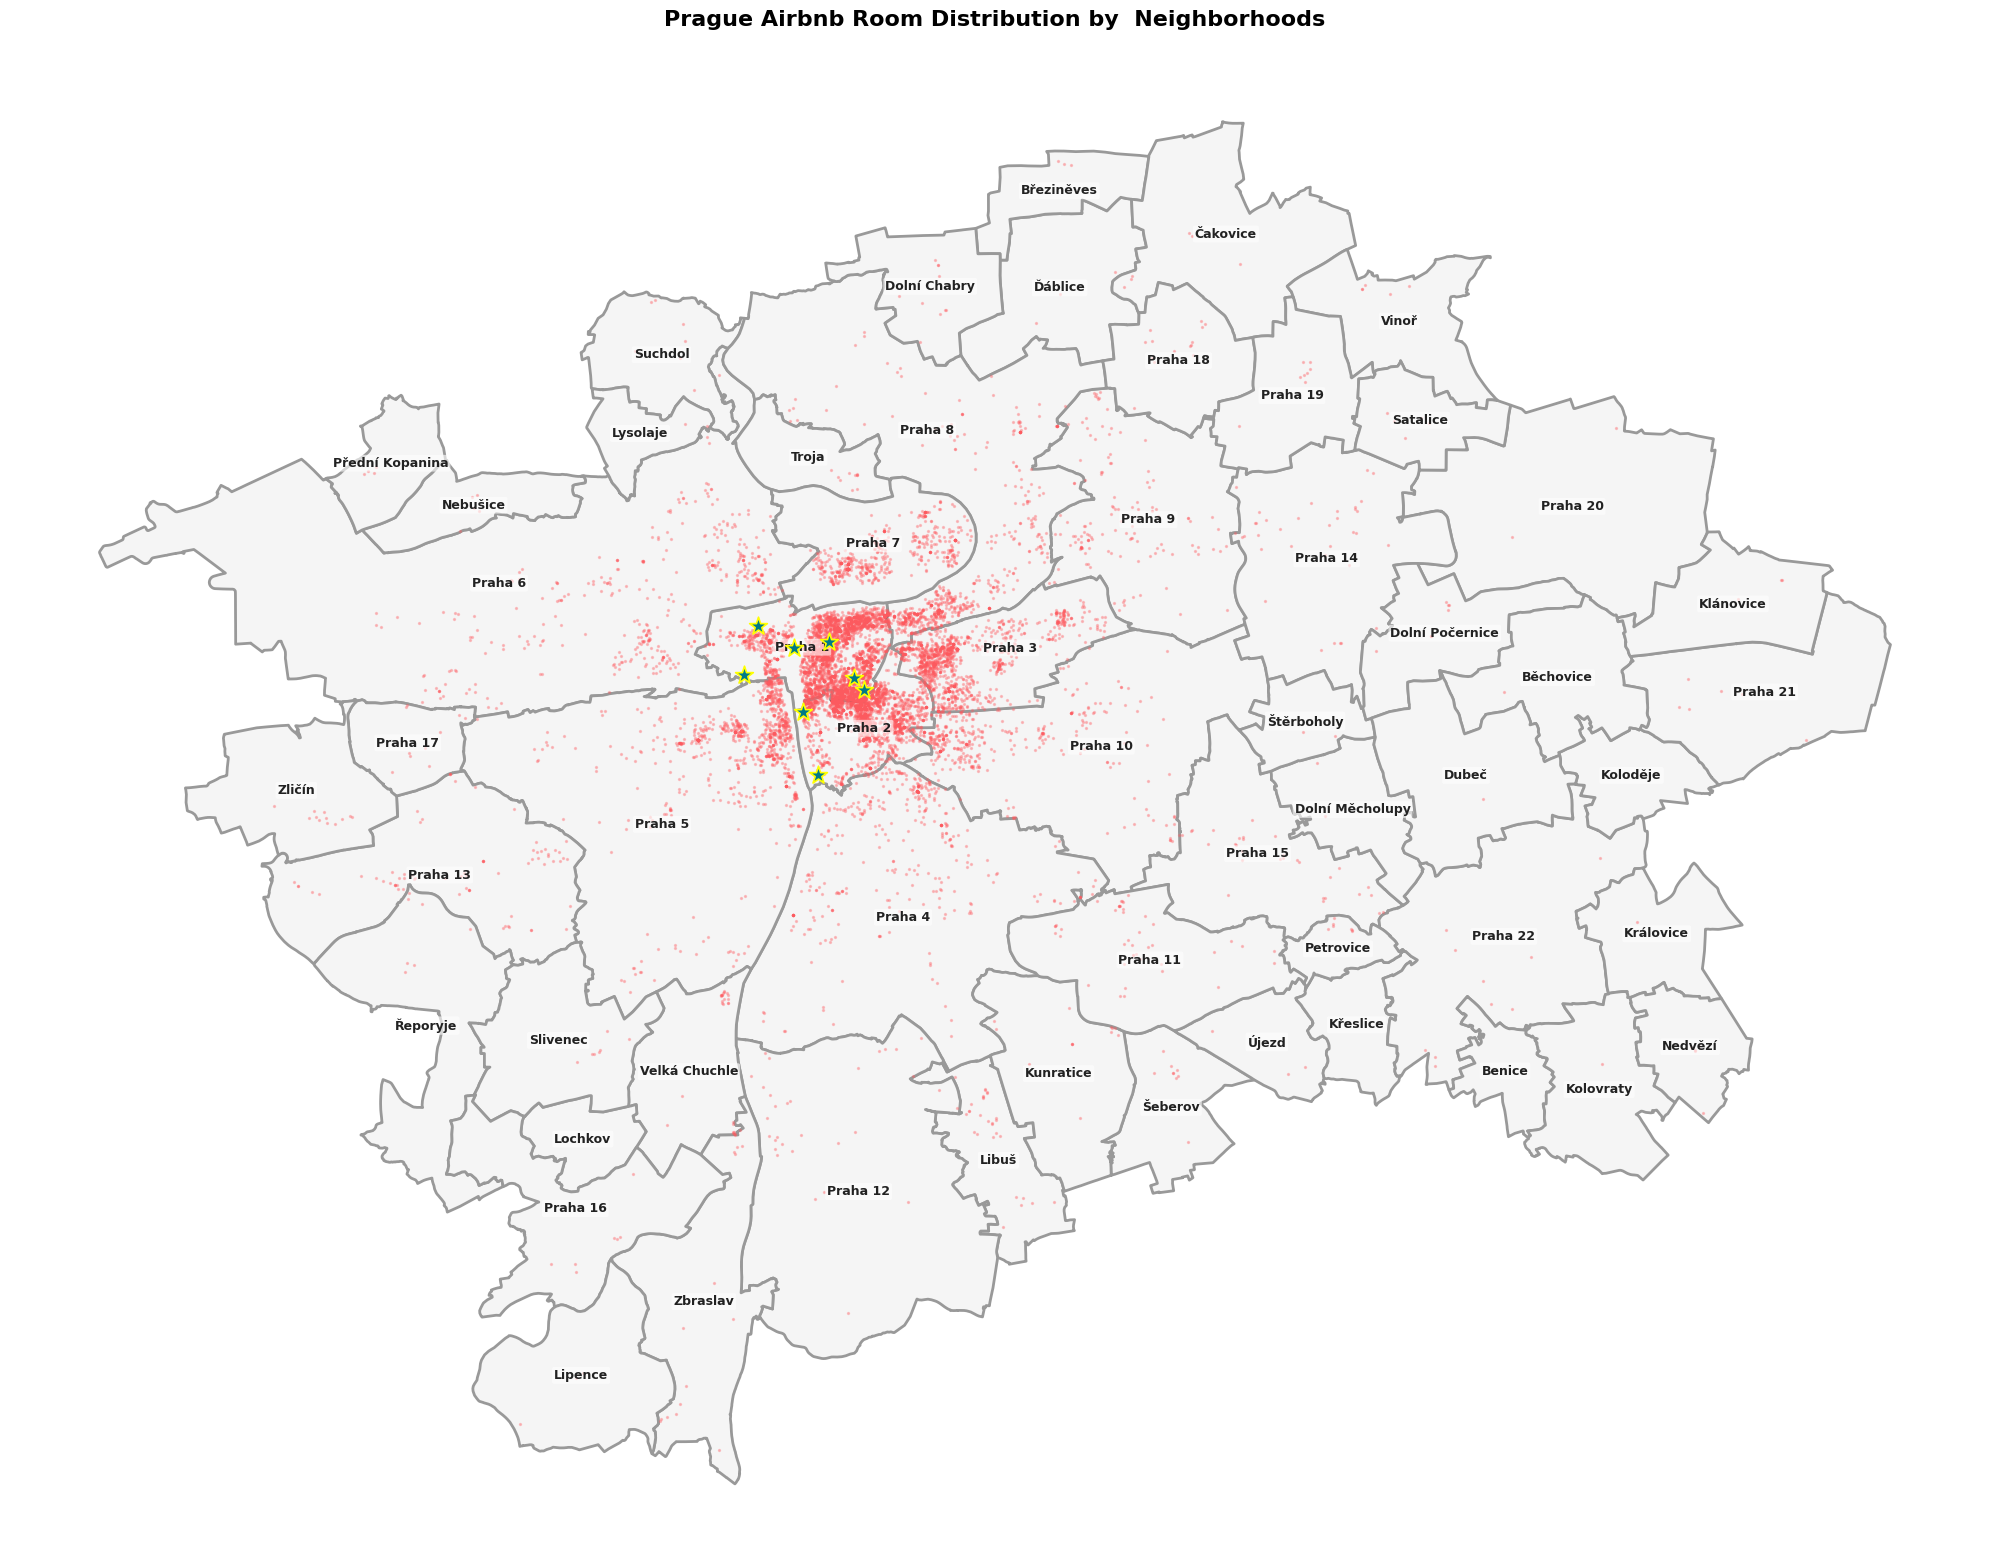

In [16]:
## Anlyze data (counts of hosts reviews, price map etc.)

#spatial distribution(accommadation supply )
# load neighbour json 

neighbor_geo_df = get_release_geodf("neighbourhoods.geojson",  "data")

#plot the supply of accomadations in Prague map and add the sightseeings in Prague(google)
fig, ax = plt.subplots(figsize=(20, 20))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

neighbor_geo_df.plot(
    ax=ax, 
    color='#F5F5F5',      # Light grey background
    edgecolor='#999999',  # Darker grey borders for sharp contrast
    linewidth=2
)

for idx, row in neighbor_geo_df.iterrows():
    # Automatically calculate the geometric center (X: Longitude, Y: Latitude)
    centroid = row['geometry'].centroid
    
    # Get the English label (e.g., "Prague 1", "Prague 2")
    neighborhood_name = str(row['neighbourhood'])
    
    
        
    # Draw text labels
    ax.text(
        x=centroid.x, 
        y=centroid.y, 
        s=neighborhood_name, 
        fontsize=9,              # Slightly smaller font to fit Prague 1 area better
        fontweight='bold',       # Bold styling
        color='#222222',         # Dark charcoal color for high readability
        ha='center',             # Horizontal alignment
        va='center',             # Vertical alignment
        # Add a subtle semi-transparent white box behind text to overlay points neatly
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.15')
    )


# layer 3: Scatter Prices
ax.scatter(
    listings_df['longitude'], 
    listings_df['latitude'], 
    color='#FF5A5F',            # Airbnb signature color
    alpha=0.3,                  # Lower alpha to keep text readable
    s=2,                         # Point size
    zorder=2                    # Force to be on the bottom layer
)

ax.set_title(
    "Prague Airbnb Listings Distribution by Administrative Neighborhoods", 
    fontsize=16, 
    fontweight='bold', 
    pad=20
)
# layer sightseeings in Prague
attractions = {
    'Charles Bridge': (14.4114, 50.0865),
    'Prague Castle': (14.4018, 50.0902),
    'Old Town Square': (14.4208, 50.0875),
    'Wenceslas Square': (14.4276, 50.0813),
    'Dancing House': (14.4140, 50.0754),
    'Petrin Tower': (14.3981, 50.0818),
    'Vysehrad': (14.4180, 50.0644),
    'National Museum': (14.4302, 50.0792)
}
# Extract Longitudes (X) and Latitudes (Y) for sightseeing
attraction_longs = [coords[0] for coords in attractions.values()]
attraction_lats = [coords[1] for coords in attractions.values()]

# Plot Landmarks as Big Golden/Blue Stars
ax.scatter(
    attraction_longs, 
    attraction_lats, 
    color='#007A87',            # Deep Cyan/Teal for strong contrast against red dots
    marker='*',                 # Star Shape
    s=180,                      # Large Size
    edgecolor='yellow',          # Black outline to pop out
    linewidth=1.2,
    zorder=5,                   # Force to be on the very top layer
    
)
# Title Definition
ax.set_title(
    "Prague Airbnb Room Distribution by  Neighborhoods", 
    fontsize=16, 
    fontweight='bold', 
    pad=20
)

ax.axis('off')  # Hide coordinates for a clean dashboard look

plt.tight_layout()
plt.show()

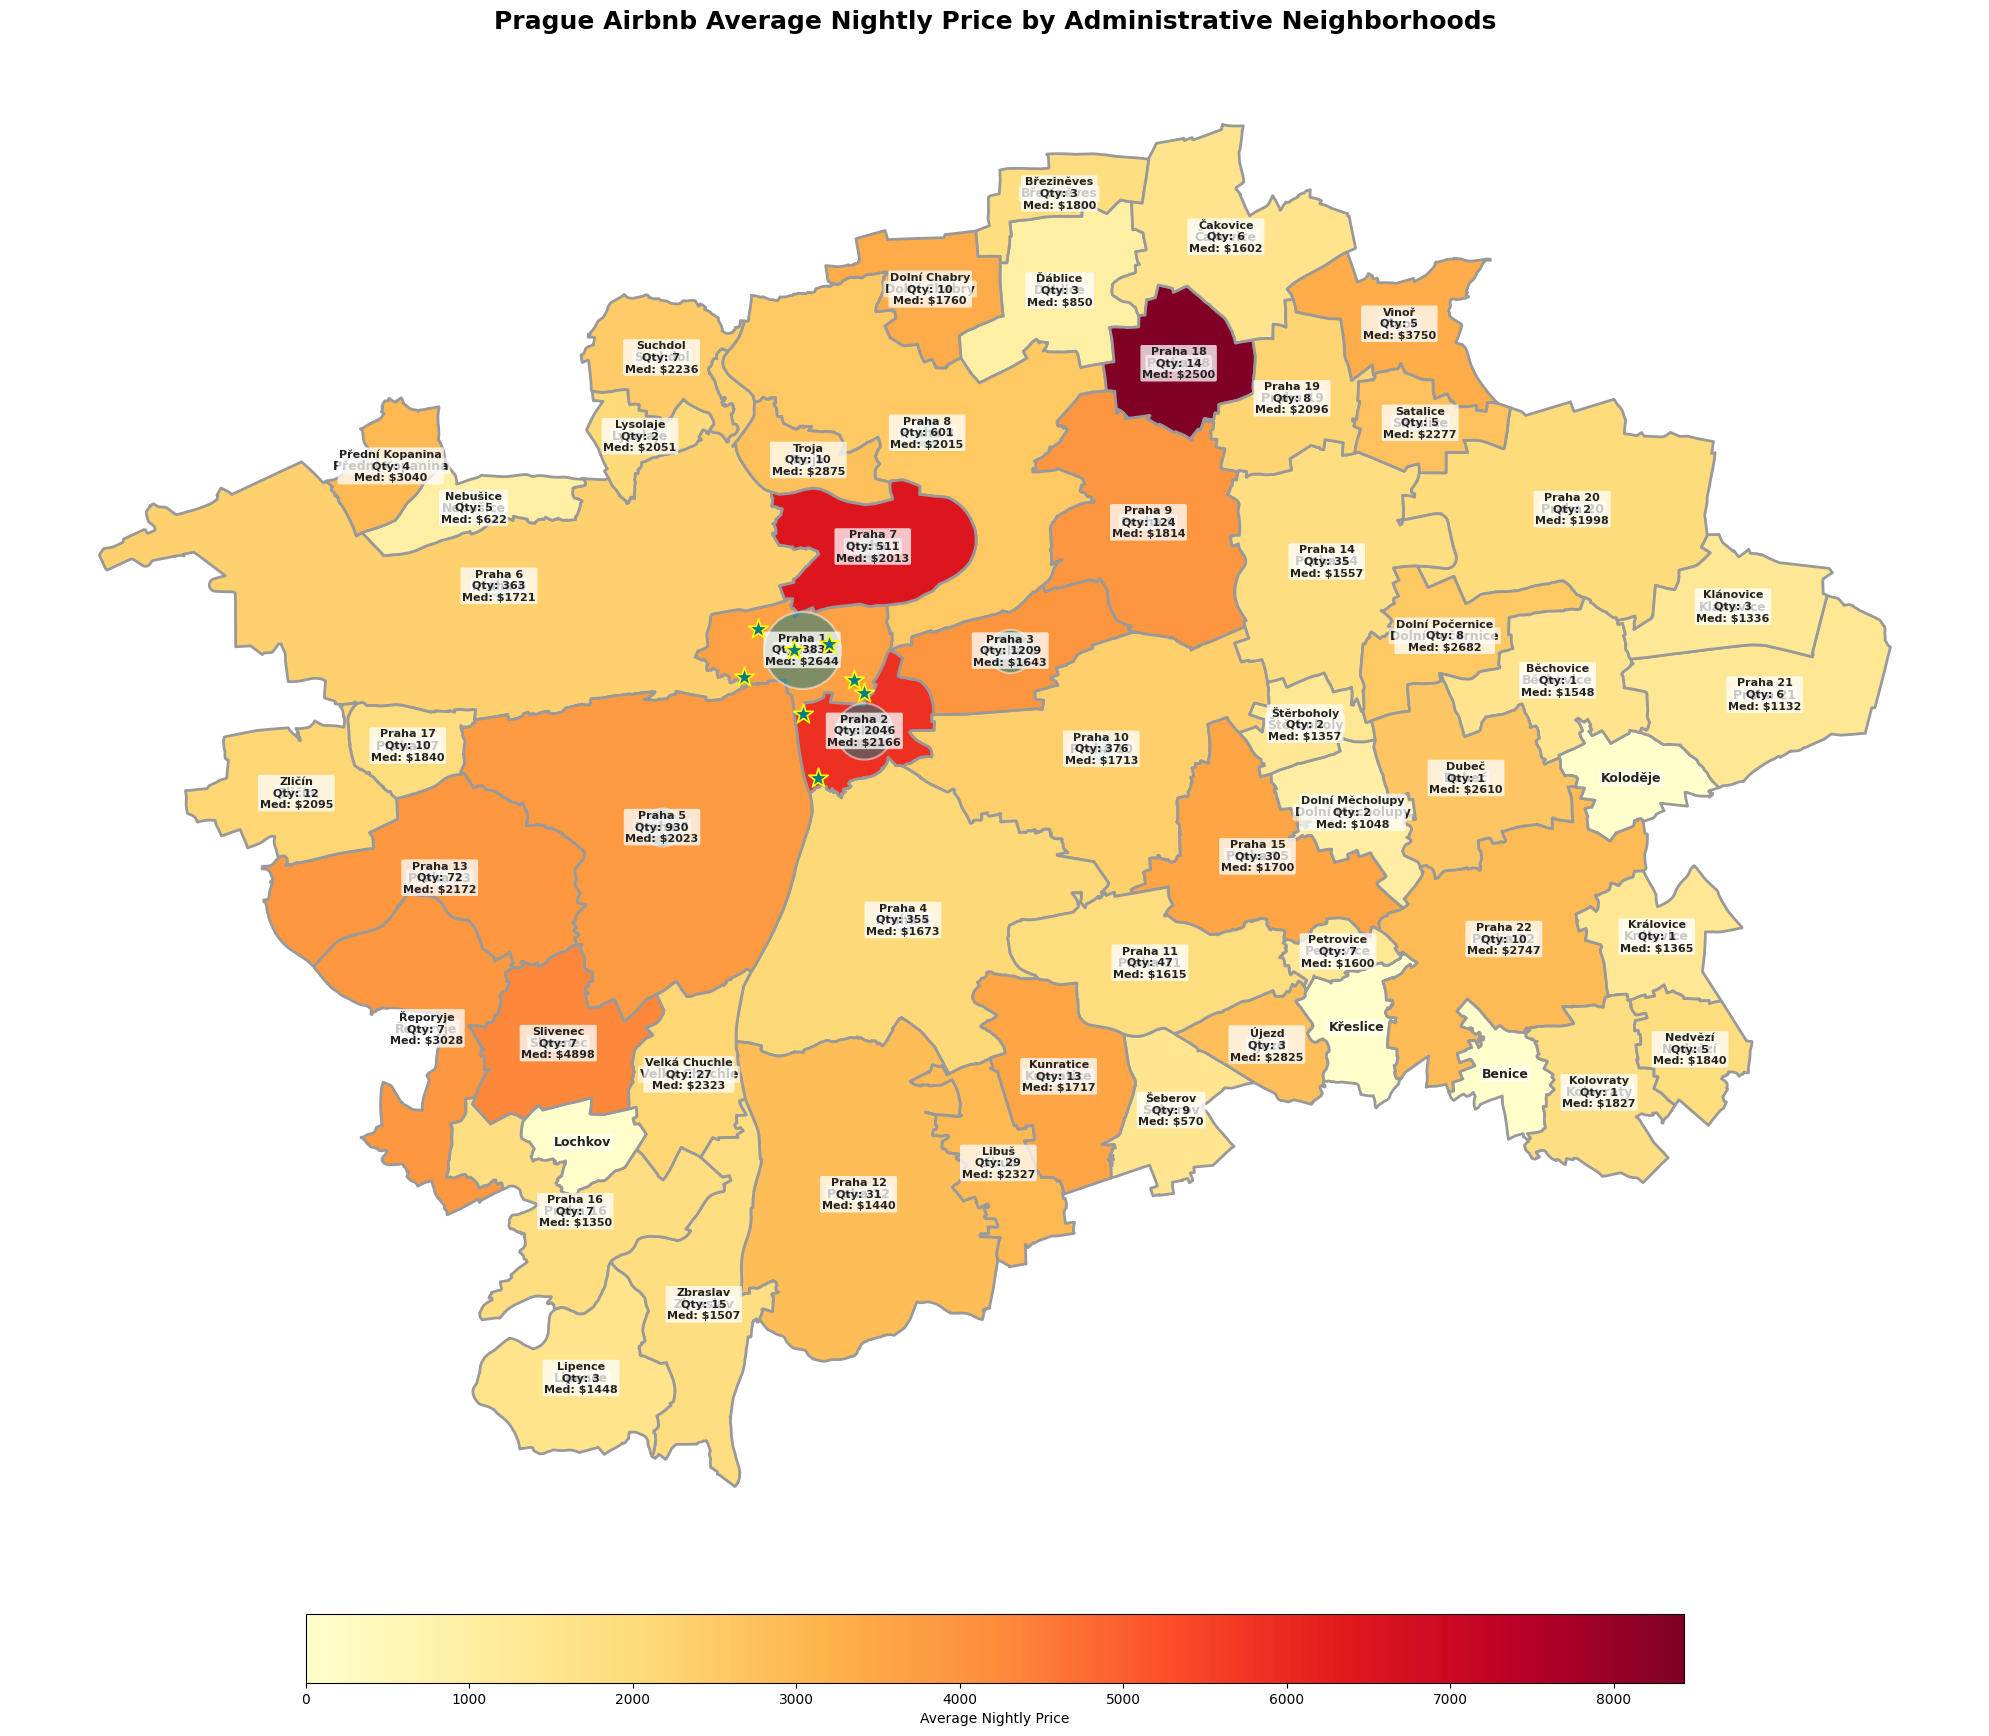

In [17]:
## the most rooms or flats are in the central area and around the sightseeings.
## the average price in different district
## the provided number of room in the district


# Convert listings to GeoDataFrame using coordinates
geometry = [Point(xy) for xy in zip(listings_df['longitude'], listings_df['latitude'])]
listings_gdf = gpd.GeoDataFrame(listings_df, geometry=geometry, crs="EPSG:4326")

# Spatial join to map every listing into a neighborhood polygon
joined_df = gpd.sjoin(listings_gdf, neighbor_geo_df, how="left", predicate="within")

# Group by district and calculate average price


stats_df = joined_df.groupby('neighbourhood_right').agg(
    avg_price=('price', 'mean'),
    listing_count=('id', 'count'),
    median_price=('price','median')
).reset_index()

stats_df.columns = ['neighbourhood', 'avg_price', 'listing_count','median_price']



# Merge back to map
map_df = neighbor_geo_df.merge(stats_df, on='neighbourhood', how='left')
map_df['avg_price'] = map_df['avg_price'].fillna(0)
map_df['listing_count'] = map_df['listing_count'].fillna(0)
map_df['median_price'] = map_df['median_price'].fillna(0)



# 0. Canvas Plotting

fig, ax = plt.subplots(figsize=(20, 20))
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False


#  Layer 1: Draw Colored Neighborhoods Map (Choropleth based on Average Price)

map_plot = map_df.plot(
    ax=ax, 
    column='avg_price',
    cmap='YlOrRd',        
    edgecolor='#999999',  # Darker borders for sharp contrast
    linewidth=2,
    legend=True,          # Adds a professional color bar
    legend_kwds={'label': "Average Nightly Price", 'orientation': "horizontal", 'pad': 0.03, 'shrink': 0.7},
    zorder=1
)


# Layer 2: Draw District Text Labels inside Bubbles (Comparing Counts and Median Prices)
for idx, row in map_df.iterrows():
    centroid = row['geometry'].centroid
    neighborhood_name = str(row['neighbourhood'])
    count = row['listing_count']
    med_p = row['median_price']
    
    if neighborhood_name.lower() in ['nan', 'none', ''] or count == 0:
        continue
    
    # Draw bubble sized by listing count
    bubble_size = count * 0.8
    ax.scatter(
        centroid.x, centroid.y,
        s=bubble_size,
        color='#007A87',       # Deep Cyan/Teal
        alpha=0.5,             
        edgecolor='white',
        linewidth=1.5,
        zorder=3
    )
        
    # Inject both metrics into the label text
    label_text = f"{neighborhood_name}\nQty: {int(count)}\nMed: ${int(med_p)}"
    ax.text(
        x=centroid.x, 
        y=centroid.y, 
        s=label_text, 
        fontsize=8,              
        fontweight='bold',       
        color='#222222',         
        ha='center',             
        va='center',             
        zorder=4,                
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.15')
    )



# Layer 3: Draw District Text Labels
for idx, row in map_df.iterrows():
    centroid = row['geometry'].centroid
    neighborhood_name = str(row['neighbourhood'])
    
    if neighborhood_name.lower() in ['nan', 'none', '']:
        continue
        
    ax.text(
        x=centroid.x, 
        y=centroid.y, 
        s=neighborhood_name, 
        fontsize=9,              
        fontweight='bold',       
        color='#222222',         
        ha='center',             
        va='center',             
        zorder=3,                # Stays on top of map background
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.15')
    )


# Layer 4: Tourist Sightseeings (No text labels, just anchors)
attractions = {
    'Charles Bridge': (14.4114, 50.0865),
    'Prague Castle': (14.4018, 50.0902),
    'Old Town Square': (14.4208, 50.0875),
    'Wenceslas Square': (14.4276, 50.0813),
    'Dancing House': (14.4140, 50.0754),
    'Petrin Tower': (14.3981, 50.0818),
    'Vysehrad': (14.4180, 50.0644),
    'National Museum': (14.4302, 50.0792)
}

attraction_longs = [coords[0] for coords in attractions.values()]
attraction_lats = [coords[1] for coords in attractions.values()]

# Plot Landmarks as Big Stars overlapping the price map
ax.scatter(
    attraction_longs, 
    attraction_lats, 
    color='#007A87',            # Deep Cyan/Teal for contrast
    marker='*',                 
    s=220,                      
    edgecolor='yellow',         
    linewidth=1.2,
    zorder=5,                   # Always on the very top
)


# Title and Layout
ax.set_title(
    "Prague Airbnb Average Nightly Price by Administrative Neighborhoods", 
    fontsize=18, 
    fontweight='bold', 
    pad=20
)

ax.axis('off')  # Hide coordinates
plt.tight_layout()
plt.show()

________________________________
####Results:
##### see the price and host counts in the central area.
##### Pragha 2 and 3 are located in the old town and there are some sightseeings, the number of room and the price of room are both at the higher levels.
##### The attractive zones follow a 45-degree axis from west to east. In this area the average price is a bit higher.
##### But in Praha 18, the price is extreme high, but the number of rented flats are at lower level. SO need to investigate maybe the type of Airbnb is different, high-value properties.
__________________________________

In [18]:
#Investigation in Praha 18
# select listings for Praha 18 safely using index intersection to avoid KeyError
idx = joined_df[joined_df['neighbourhood_right'] == 'Praha 18'].index
idx = idx.intersection(listings_df.index)
praha18_listings = listings_df.loc[idx]
praha18_listings



,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_since_clean,calendar_last_scraped_clean,first_review_clean,last_review_clean
2433,33087733,Penthouse Letňanské zahrady,Modern new accommodation in a quiet area with ...,To the center 20 minutes by public transport a...,6529923,Kamil,2013-05-22,NaN,NaN,within an hour,...,f,1,1,0,0,2.48,4762.0,255,2609.0,256.0
3097,42469578,Mykhailo Apartment,Simple and cozy apartment. It has everything ...,NaN,338152160,Mykhailo,2020-02-22,NaN,NaN,NaN,...,f,1,1,0,0,NaN,2295.0,255,NaN,NaN
4219,628736661280986698,Útulný byteček 1+kk s terasou a zahrádkou,In the vicinity of the apartment there is a Le...,NaN,459521701,Dominik,2022-05-17,NaN,NaN,within an hour,...,t,1,1,0,0,0.62,1480.0,255,1459.0,296.0
5926,939887695682639290,"Room in shared apartment, Prague Letňany",Nice room in shared apartment with 2 rooms an...,NaN,6145656,Lounes,2013-04-29,"Prague, Czechia",I like travling and meeting new people from d...,within an hour,...,f,2,1,1,0,0.23,4785.0,255,1025.0,348.0
6523,1039111509619360155,Prague Letnany PVA Expo Apartment,"Make yourself at home in this quiet, stylish, ...",NaN,447192411,Anna,2022-02-28,"Prague, Czechia",NaN,within a day,...,f,2,2,0,0,2.27,1558.0,255,796.0,271.0
7068,1125430328237139605,Beautiful Spacious house w/garage & free parking,Unwind at our stunning double storey house loc...,NaN,57420672,Anna,2016-02-04,"Prague, Czechia",Hi! My name is Anna. I've been living in Pragu...,within an hour,...,f,2,2,0,0,3.39,3774.0,255,767.0,276.0
7389,1165072187721537348,Byt se zimní zahradou,Relax and unwind in this peaceful oasis.,NaN,207098320,Alena,2018-08-03,NaN,NaN,within an hour,...,f,2,2,0,0,1.28,2863.0,255,722.0,270.0
7391,1165330659899874471,parking v podzemí garáži zdarma,Relax and unwind in this peaceful oasis.,NaN,207098320,Alena,2018-08-03,NaN,NaN,within an hour,...,f,2,2,0,0,0.13,2863.0,254,700.0,661.0
7928,1232362603899838919,Brand new apartment in Letnany,Cosy apartment with great design and everythin...,NaN,447192411,Anna,2022-02-28,"Prague, Czechia",NaN,within a day,...,f,2,2,0,0,0.17,1558.0,255,612.0,348.0
9888,1440089202757866219,Krásný Mezonet 20 min od centra!,This apartment charm with a place. In a small ...,NaN,206446798,Stepanka,2018-07-31,"Prague, Czechia",NaN,within an hour,...,f,1,1,0,0,1.50,2866.0,255,354.0,294.0


##### just a few room provided in this area and there is one room whose price reaches 77777. 
##### The price seems not to be a normal price and make the average price quite high.
##### right now the rooms or flats are concentrated in the city center and in the rural district the prices are little lower. the results are very consistent with the common sence.


____________________________
#### 2.Feature Selection

##### numeric data
##### categorical data
##### boolean data




_____________________________

##### Numerical data


In [19]:

numeric_cols = listings_df.select_dtypes(include=[np.number]).columns.tolist()
other_cols = listings_df.columns.difference(numeric_cols).tolist()



In [20]:
#the first selection of numerical data
clean_numeric_cols = [
 'host_response_rate',
 'host_acceptance_rate',
 'host_listings_count',
 'host_total_listings_count',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'host_since_clean',
 'first_review_clean',
 'last_review_clean']


In [21]:
# 1. summarize the data and skey detection

summary_dict = {
    col: {
        'min': listings_df[col].min(),
        'max': listings_df[col].max(),
        'mean': round(listings_df[col].mean(), 4) if listings_df[col].mean() is not None else None,
        'nulls': listings_df[col].isna().sum(),
        'unique': listings_df[col].nunique(dropna=True),
        'skew': round(listings_df[col].skew(), 4)
    }
    for col in clean_numeric_cols
}
eda_summary_df = pd.DataFrame(summary_dict).T
print(eda_summary_df)
SKEW_THRESHOLD = 0.75
need_log_cols = eda_summary_df[eda_summary_df["skew"] > SKEW_THRESHOLD].index.tolist()

print("skew feature：", need_log_cols)

                                                 min          max  \
host_response_rate                              0.00         1.00   
host_acceptance_rate                            0.00         1.00   
host_listings_count                             0.00      1468.00   
host_total_listings_count                       0.00      8772.00   
accommodates                                    1.00        16.00   
bathrooms                                       0.00        20.00   
bedrooms                                        0.00        34.00   
beds                                            0.00        32.00   
price                                         223.00    632000.00   
minimum_nights                                  1.00      1124.00   
maximum_nights                                  1.00      3333.00   
minimum_minimum_nights                          1.00      1124.00   
maximum_minimum_nights                          1.00      1124.00   
minimum_maximum_nights            

In [22]:
#log numeric data and get the final data for correlation filter
final_corr_cols = []

for col in clean_numeric_cols:
    #if log already, then skip
    if col.endswith("_log"):
        
        base_col = col.replace("_log", "")
    else:
        base_col = col

    # need log
    if base_col in need_log_cols:
        target_log_col = f"{base_col}_log"
        if target_log_col not in listings_df.columns:
            listings_df[target_log_col] = np.log1p(listings_df[base_col])
            
        else:
            print(f"Already existed so skip")

        
        if target_log_col not in final_corr_cols:
            final_corr_cols.append(target_log_col)

    else:
        # add col to final numeric col
        if base_col not in final_corr_cols:
            final_corr_cols.append(base_col)
       
#data for correlation
final_numeric_df = listings_df[final_corr_cols]

print(final_corr_cols)

['host_response_rate', 'host_acceptance_rate', 'host_listings_count_log', 'host_total_listings_count_log', 'accommodates_log', 'bathrooms_log', 'bedrooms_log', 'beds_log', 'price_log', 'minimum_nights_log', 'maximum_nights_log', 'minimum_minimum_nights_log', 'maximum_minimum_nights_log', 'minimum_maximum_nights', 'maximum_maximum_nights_log', 'minimum_nights_avg_ntm_log', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews_log', 'number_of_reviews_ltm_log', 'number_of_reviews_l30d_log', 'availability_eoy', 'number_of_reviews_ly_log', 'estimated_occupancy_l365d', 'estimated_revenue_l365d_log', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count_log', 'calculated_host_listings_count_entire_homes_log', 'calculated_host_listings_count_private_rooms_log', 'calc

In [23]:
final_corr_cols


['host_response_rate',
 'host_acceptance_rate',
 'host_listings_count_log',
 'host_total_listings_count_log',
 'accommodates_log',
 'bathrooms_log',
 'bedrooms_log',
 'beds_log',
 'price_log',
 'minimum_nights_log',
 'maximum_nights_log',
 'minimum_minimum_nights_log',
 'maximum_minimum_nights_log',
 'minimum_maximum_nights',
 'maximum_maximum_nights_log',
 'minimum_nights_avg_ntm_log',
 'maximum_nights_avg_ntm',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews_log',
 'number_of_reviews_ltm_log',
 'number_of_reviews_l30d_log',
 'availability_eoy',
 'number_of_reviews_ly_log',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d_log',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count_log',
 'calculated_host_listings_count_entire_homes_log',
 'calculated_host_lis

Put the price_log in the first column


<Figure size 2000x2000 with 0 Axes>

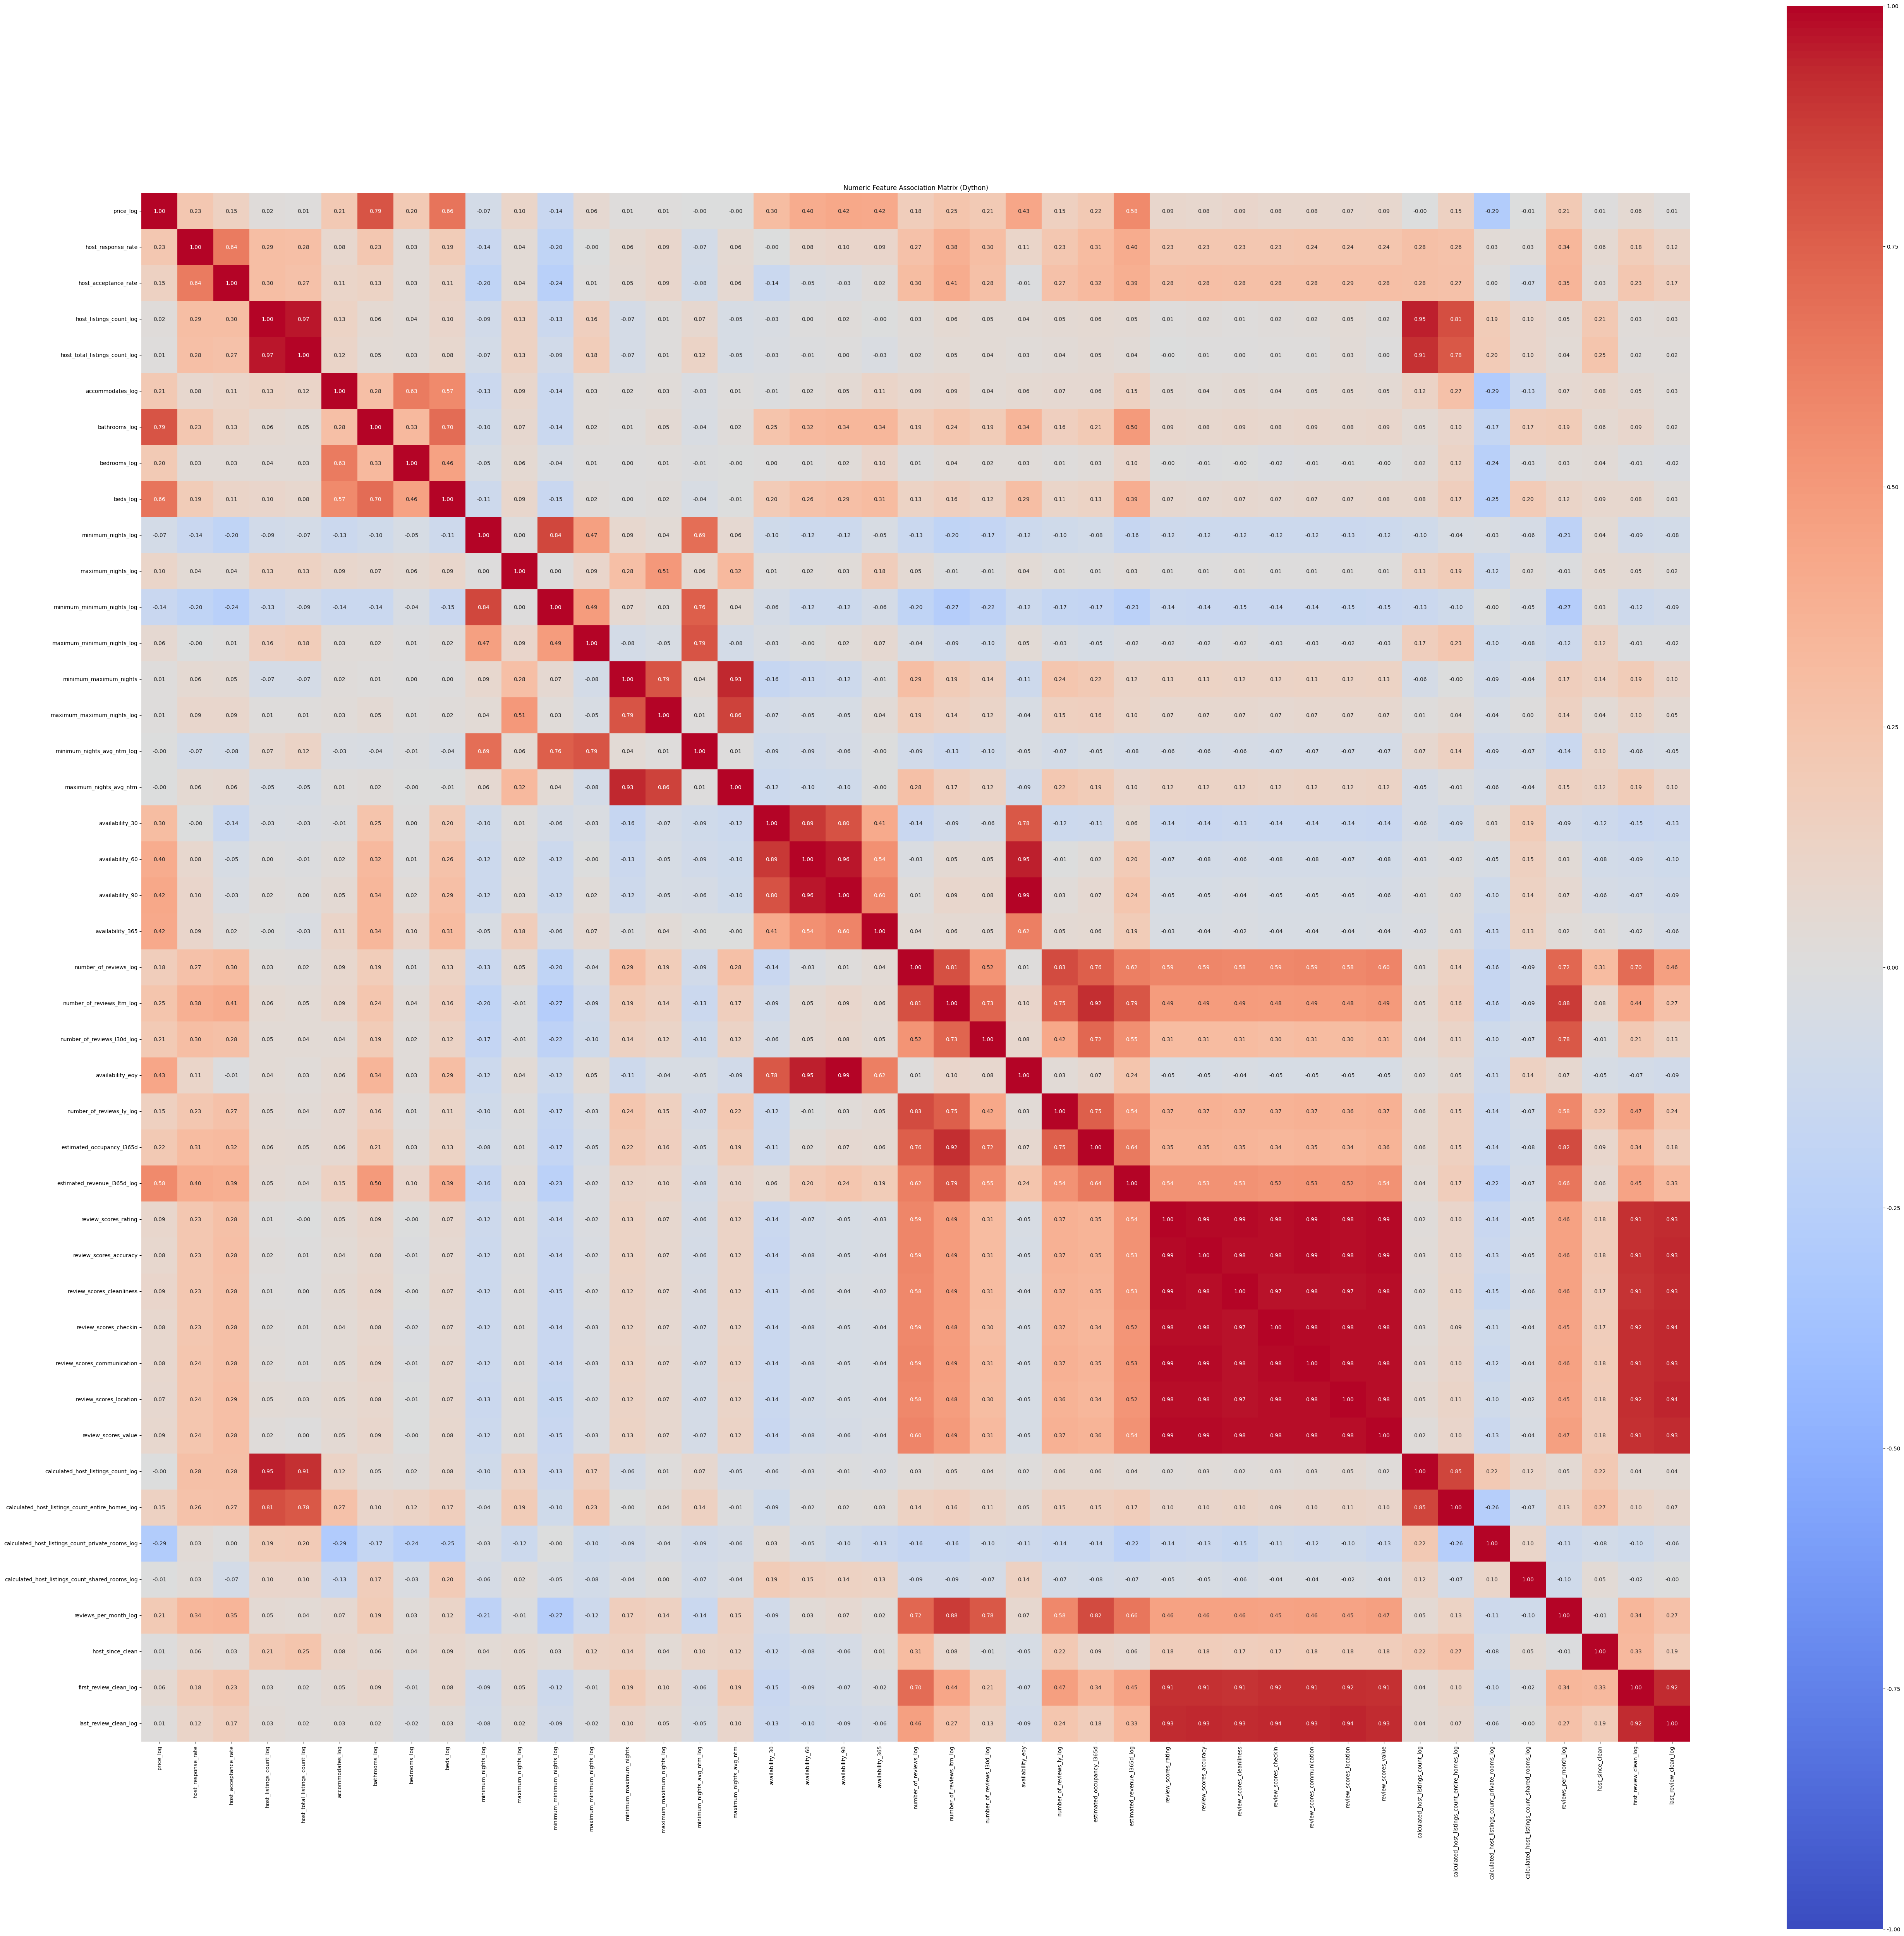

In [24]:
#investigate the correlation of feature
# heatmap
target = 'price_log'

if target in final_corr_cols:
    final_corr_cols.remove(target)
    final_corr_cols.insert(0, target)
    print(f"Put the {target} in the first column")
else:
    print(f"Warning, can't not find the {target}")  
final_numeric_df = final_numeric_df[final_corr_cols]
plt.figure(figsize=(20, 20))

output = associations(
    dataset= final_numeric_df,     
    cmap='coolwarm',                     
    numerical_columns='auto',                       
    num_num_assoc='pearson',              
    title='Numeric Feature Association Matrix (Dython)',
    vmax=1.0, vmin=-1.0,                 
    fmt='.2f',                            
    annot=True                          
)

plt.show()

##### Notice: reviews info have very high correlation with price(Abnormal)

In [25]:
# get the correlation matrix
#1.remove the single features, which can not provide info with target(price)
#2.remove some features which has collineairy
corr_matrix = output['corr']
#remove the target corralation
price_correlations = corr_matrix[target].drop(target)
#
#THRESHOLD = 0.1

# get the inofrmative columns
passed_features = price_correlations[price_correlations.abs() >= 0.1].index.tolist()
dropped_features = price_correlations[price_correlations.abs() < 0.1].index.tolist()
# selected feature matrix
reduced_matrix = corr_matrix.loc[passed_features, passed_features].abs()

# remove the multicollinearity
#sysmetric matrix, get the upper matrix
upper_tri = reduced_matrix.where(np.triu(np.ones(reduced_matrix.shape), k=1).astype(bool))

# multicollinearity between features
to_drop_collinearity = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

# final features
final_features = [f for f in passed_features if f not in to_drop_collinearity]

print(f"\n highly correlated data：{to_drop_collinearity}removed")
print(f"final remaining features(total  {len(final_features)} columns）：\n{final_features}")


 highly correlated data：['availability_90', 'availability_eoy']removed
final remaining features(total  20 columns）：
['host_response_rate', 'host_acceptance_rate', 'accommodates_log', 'bathrooms_log', 'bedrooms_log', 'beds_log', 'maximum_nights_log', 'minimum_minimum_nights_log', 'availability_30', 'availability_60', 'availability_365', 'number_of_reviews_log', 'number_of_reviews_ltm_log', 'number_of_reviews_l30d_log', 'number_of_reviews_ly_log', 'estimated_occupancy_l365d', 'estimated_revenue_l365d_log', 'calculated_host_listings_count_entire_homes_log', 'calculated_host_listings_count_private_rooms_log', 'reviews_per_month_log']


##### categorical data

In [26]:
categorical_cols = ['host_location','host_response_time','host_verifications','neighbourhood_cleansed','property_type','room_type']


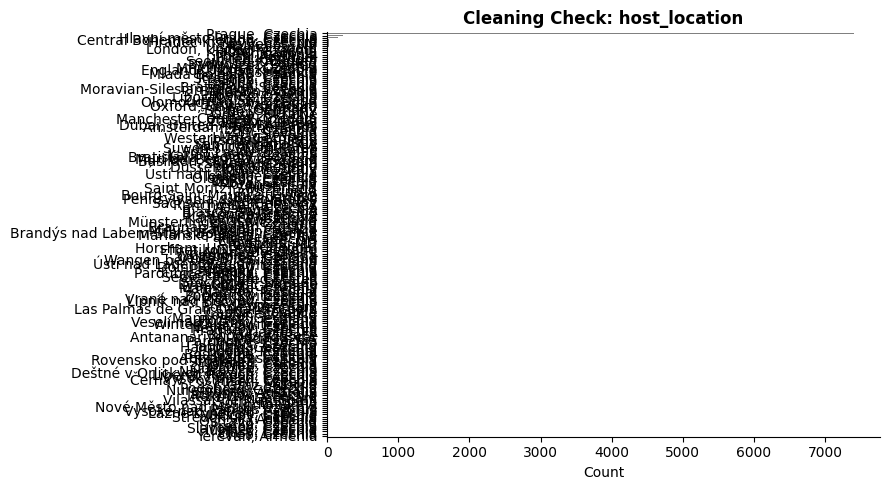

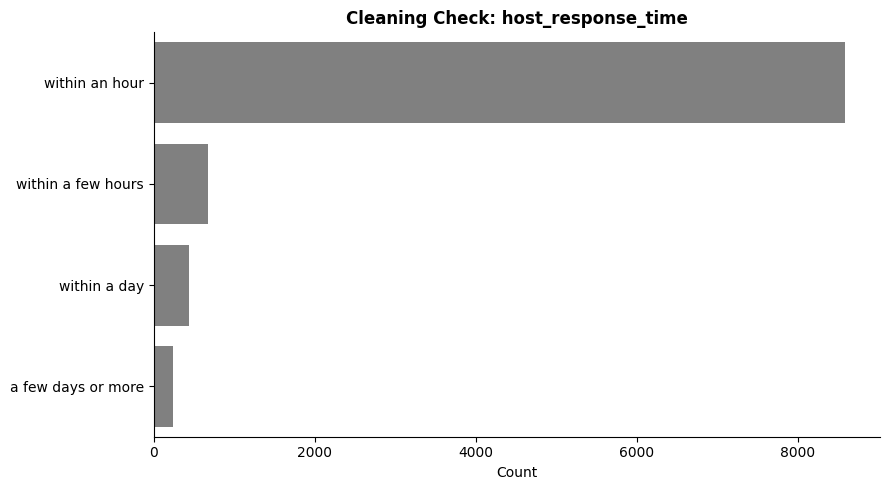

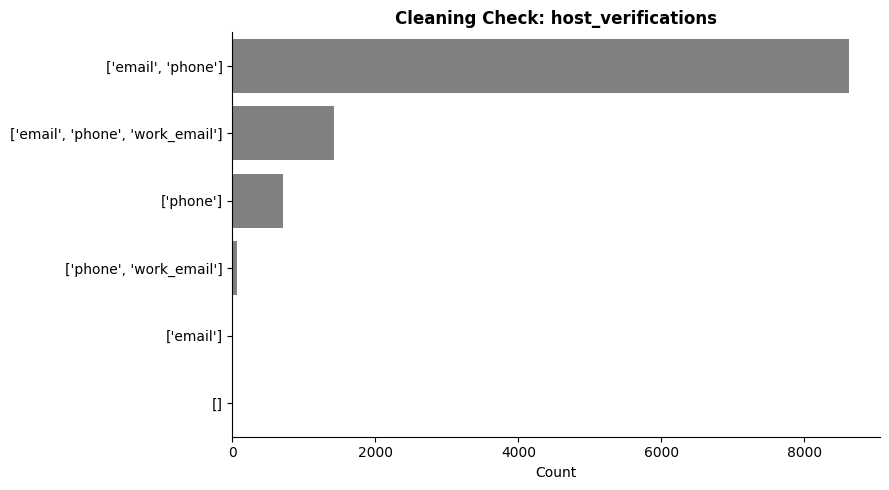

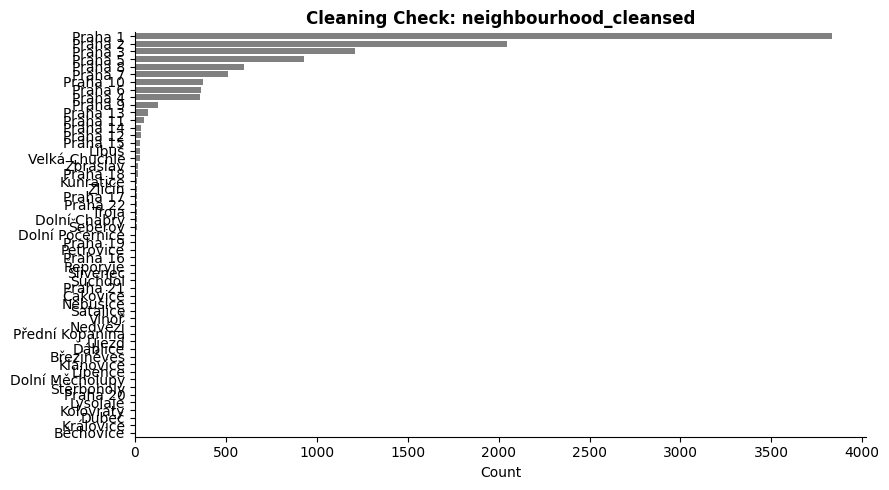

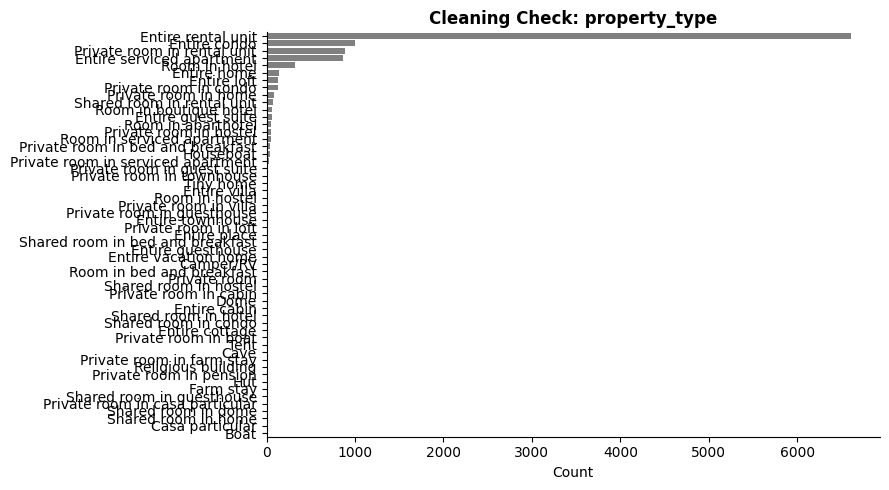

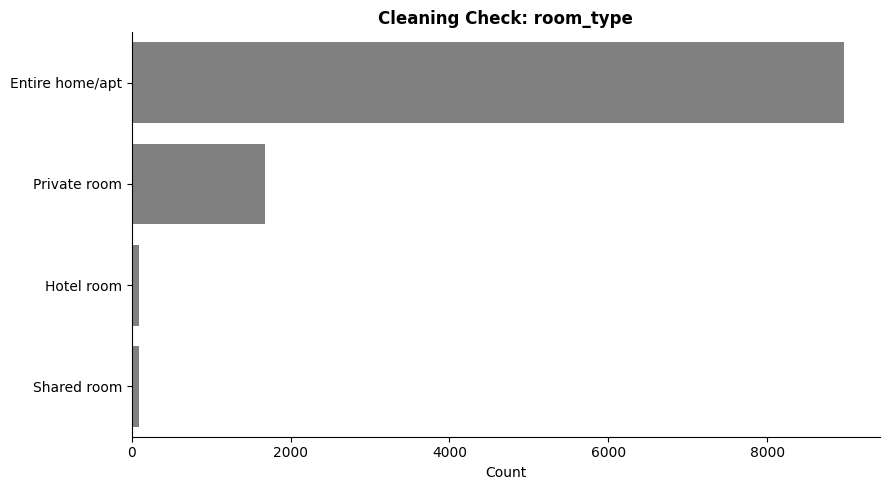

In [27]:
# categories of data
for col in categorical_cols:
   
    plt.figure(figsize=(9, 5)) 
    
    #count of every category
    sns.countplot(
        data=listings_df, 
        y=col, 
        order=listings_df[col].value_counts().index, 
        color='gray' 
    )
    #polish
    plt.title(f"Cleaning Check: {col}", fontsize=12, fontweight='bold')
    plt.xlabel("Count")
    plt.ylabel("")
    sns.despine()
    
    plt.tight_layout()
    plt.show()

In [28]:
#categerical data merge
## Top 5 data and the rest is 'other'
clean_categorical_cols = []

for col in categorical_cols:
    target_col = f"{col}_clean"
    col_series = listings_df[col].value_counts(dropna=True)

    if col_series.size > 5:
        if target_col not in listings_df.columns:
            top_5 = col_series.head(5).index
            listings_df[target_col] = listings_df[col].apply(
                lambda x: x if pd.notna(x) and x in top_5 else "Other"
            )

        
        if target_col not in clean_categorical_cols:
            clean_categorical_cols.append(target_col)
        
    else:
        listings_df[col] = listings_df[col].fillna("Other")

        
        if col not in clean_categorical_cols:
            clean_categorical_cols.append(col)
print(clean_categorical_cols,categorical_cols)
print(f"Check the length of the edited col and the original columns: {len(categorical_cols)==len(clean_categorical_cols)}")

if not len(categorical_cols)==len(clean_categorical_cols):
    print("\nPlease check the reason")


['host_location_clean', 'host_response_time', 'host_verifications_clean', 'neighbourhood_cleansed_clean', 'property_type_clean', 'room_type'] ['host_location', 'host_response_time', 'host_verifications', 'neighbourhood_cleansed', 'property_type', 'room_type']
Check the length of the edited col and the original columns: True


In [29]:
#one-hot
categerical_df = listings_df[clean_categorical_cols].copy()

for col in clean_categorical_cols:
    categerical_df[col] = categerical_df[col].astype(str)

one_hot_encoded_df = pd.get_dummies(
    categerical_df, columns=clean_categorical_cols, drop_first=True, dtype=int
)

one_hot_encoded_df_cols = one_hot_encoded_df.columns

print(f"\n {one_hot_encoded_df.shape[1]}")



 27


In [30]:
one_hot_encoded_df.head()

,host_location_clean_Czechia,"host_location_clean_Hlavní město Praha, Czechia","host_location_clean_Hradec Kralove, Czechia",host_location_clean_Other,"host_location_clean_Prague, Czechia",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,"host_verifications_clean_['email', 'phone', 'work_email']",...,neighbourhood_cleansed_clean_Praha 5,neighbourhood_cleansed_clean_Praha 8,property_type_clean_Entire rental unit,property_type_clean_Entire serviced apartment,property_type_clean_Other,property_type_clean_Private room in rental unit,property_type_clean_Room in hotel,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,0,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


##### Boolean data


In [31]:
bool_cols = ['has_availability','host_has_profile_pic','host_identity_verified','host_is_superhost','instant_bookable']
# 1. true or false dict map
bool_map = {'t': 1, 'f': 0, 'True': 1, 'False': 0, 'T': 1, 'F': 0,True: 1, False: 0,}
# 2. t->1 else 0
for col in bool_cols:
    #check the type of column
    #if is_string_dtype(listings_df[col]) and not is_bool_dtype(listings_df[col]):
    listings_df[col] = listings_df[col].map(bool_map).fillna(0).astype(int)
   

In [32]:
#celaned categorical data and feature selection( one feature and correlation of feature)
clean_categorical_df = pd.concat([one_hot_encoded_df, listings_df[bool_cols+[target]]], axis=1)
X = clean_categorical_df.dropna(subset=[target]).drop(columns=[target])
y = clean_categorical_df.dropna(subset=[target])[target]

In [33]:
clean_categorical_df.head()

,host_location_clean_Czechia,"host_location_clean_Hlavní město Praha, Czechia","host_location_clean_Hradec Kralove, Czechia",host_location_clean_Other,"host_location_clean_Prague, Czechia",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,"host_verifications_clean_['email', 'phone', 'work_email']",...,property_type_clean_Room in hotel,room_type_Hotel room,room_type_Private room,room_type_Shared room,has_availability,host_has_profile_pic,host_identity_verified,host_is_superhost,instant_bookable,price_log
0,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,1,1,1,1,NaN
1,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,1,1,1,1,NaN
2,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,1,1,1,0,7.728856
3,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,1,1,1,1,NaN
4,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,1,1,1,0,0,7.967627


In [34]:
#celaned categorical data and feature selection( one feature and correlation of feature)

clean_categorical_df = pd.concat([one_hot_encoded_df, listings_df[bool_cols+[target]]], axis=1)
X = clean_categorical_df.dropna(subset=[target]).drop(columns=[target])
y = clean_categorical_df.dropna(subset=[target])[target]


f_scores, p_values = f_regression(X, y)

# P value<0.05, not significant features.
anova_df = pd.DataFrame({"Feature": X.columns, "p_value": p_values})
significant_cols = anova_df[anova_df["p_value"] < 0.05]["Feature"].tolist()

print(f"passed one featured {len(significant_cols)} among  {X.shape[1]} features")
X_step1 = X[significant_cols]

#correlation among features
corr_matrix = X_step1.corr().abs()

# sysmatric corr matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]
print(f"redundant features{len(redundant_cols)} ")
#final categorical deatures
X_categorical_ready = X_step1.drop(columns=redundant_cols)

print(    f"\n the shape: {X_categorical_ready.shape}")

passed one featured 22 among  32 features
redundant features1 

 the shape: (9498, 21)


In [35]:
#concat numerical features and categorical features for the final feature selection in Random forest
X_numeric_ready = listings_df[final_features+[target]].dropna(subset=[target]).drop(columns=[target])
X_all = pd.concat([X_numeric_ready , X_categorical_ready], axis=1)
y_all = y
print(f"the shape of the X: {X_all.shape},y shape: {y_all.shape}")


the shape of the X: (9498, 41),y shape: (9498,)


In [36]:
#random forest, 100estimator, max_depth 5, threshold 95%
selected_features, importance_df = select_features_by_rf(X_all, y_all, 0.95, 5, 100, 42)


Beginning: original features 41 )
finished:original features 41 个 -> selected features: 11 ,cumulative importance 0.95)


In [51]:
listings_df.head()

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,...,calculated_host_listings_count_entire_homes_log,calculated_host_listings_count_private_rooms_log,calculated_host_listings_count_shared_rooms_log,reviews_per_month_log,first_review_clean_log,last_review_clean_log,host_location_clean,host_verifications_clean,neighbourhood_cleansed_clean,property_type_clean
0,23163,Residence Karolina - KAROL12,"Unique and elegant apartment rental in Prague,...",NaN,5282,Klara,2008-12-17,"Prague, Czechia","Hello, \r\nglad to see that you are interested...",within an hour,...,4.317488,0.0,0.0,0.157004,8.654866,6.580639,"Prague, Czechia","['email', 'phone']",Praha 1,Entire rental unit
1,23169,Residence Masna - Masna302,Masna studio offers a lot of space and privacy...,NaN,5282,Klara,2008-12-17,"Prague, Czechia","Hello, \r\nglad to see that you are interested...",within an hour,...,4.317488,0.0,0.0,0.506818,8.678291,5.846439,"Prague, Czechia","['email', 'phone']",Praha 1,Entire rental unit
2,26755,Central Prague Old Town Top Floor,Big and beautiful new attic apartment in the v...,This apartment offers a fantastic location. Yo...,113902,Daniel+Bea,2010-04-26,"Prague, Czechia",Hi! we are a sp/cz couple with 2 daughters (La...,within an hour,...,1.386294,0.0,0.0,1.501853,8.303009,5.609472,"Prague, Czechia","['email', 'phone']",Praha 1,Entire rental unit
3,30762,Residence Rybna - Rybna23,"We offer a modern, comfortable, serviced apart...",NaN,5282,Klara,2008-12-17,"Prague, Czechia","Hello, \r\nglad to see that you are interested...",within an hour,...,4.317488,0.0,0.0,0.095310,8.622634,5.981414,"Prague, Czechia","['email', 'phone']",Praha 1,Entire serviced apartment
4,42514,"""NEWLY FURNISHED"" 1BR near Pachtuv Palace,Old ...",*NEWLY* Furnished 1-bedroom apartment on the f...,NaN,185641,Victoria,2010-07-30,"Saint Moritz, Switzerland",I'm a mother to a 8-year old boy whom I treasu...,a few days or more,...,0.693147,0.0,0.0,1.033184,8.660601,7.032624,Other,"['email', 'phone']",Praha 1,Entire rental unit


In [54]:
#final cleaned data set
id_info = listings_df.loc[final_dataset.index, ['id','name']]
final_dataset  = pd.concat([id_info,X_all[selected_features],y_all],axis=1)


In [55]:
final_dataset.head()

,id,name,bedrooms_log,estimated_revenue_l365d_log,property_type_clean_Private room in rental unit,bathrooms_log,room_type_Shared room,host_response_rate,availability_365,estimated_occupancy_l365d,reviews_per_month_log,calculated_host_listings_count_entire_homes_log,availability_60,price_log
2,26755,Central Prague Old Town Top Floor,0.693147,13.269681,0,0.916291,0,1.00,142,255,1.501853,1.386294,11,7.728856
4,42514,"""NEWLY FURNISHED"" 1BR near Pachtuv Palace,Old ...",0.693147,0.000000,0,0.693147,0,0.33,362,0,1.033184,0.693147,57,7.967627
5,52148,Colorful 2BDR Family Apartment,0.693147,13.111114,0,0.693147,0,1.00,121,198,0.959350,4.564348,27,7.823246
6,55856,Renovated Apartment behind National Museum,0.693147,13.169297,0,0.693147,0,1.00,125,255,1.214913,4.564348,33,7.628518
7,75298,Prague Studio Old Town,0.693147,9.151333,0,0.693147,0,1.00,320,6,0.285179,1.098612,35,7.360104


In [ ]:
#store
final_dataset.to_csv("airbnb_listings_features.csv.gz", index=True, compression="gzip")
print("Success in local！")
!gh release upload data ./airbnb_listings_features.csv.gz --clobber
print("Upload in release")


Success in local！
Successfully uploaded 1 asset to data
Upload in release
